#### Dependencies

In [1]:
print('debug')

debug


In [ ]:
# ============================================================
# Standard library
# ============================================================
import gc
import json
import sys
import warnings
import os 
from pathlib import Path
from typing import Dict, Generator, List, Tuple

# ============================================================
# Third-party libraries
# ============================================================
import lightgbm as lgb
import numpy as np
import pandas as pd
import pyarrow as pa
import xgboost as xgb
from pandas.api.types import CategoricalDtype
from scipy.stats import poisson, spearmanr
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, log_loss
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import optuna 
from optuna.importance import get_param_importances
import matplotlib.pyplot as plt
# ============================================================
# Configuration
# ============================================================
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

# ============================================================
# Project paths
# ============================================================
PROJECT_ROOT = Path.cwd().parents[2]
sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
CONFIG_PATH = PROJECT_ROOT / "configs" / "1x2"
# ============================================================
# Project modules
# ============================================================

from src.utils.utils import (
      split_data,
      clean_key_missing,
      prepare_data_for_training,
      align_frame_to_reference,
      assert_same_categorical_schema,
      categorical_columns,
  )

from src.preprocessing.preprocessing import (
    corregir_marcadores_90,
    preprocessing_1x2_extra_time_filter,
    clean_dataset,
)

from src.metrics.metrics import (
    calculate_rps,
    log_loss,
    calculate_ece,
    evaluate_model,
)

from src.evaluation.evaluation import (
    calculate_rps_single,
    get_vectorized_rps,
)

from src.training.training import (
    train_and_evaluate_lgbm,
    timeseries_cv_evaluate,
    apply_target_encoding_to_validation,
    run_logistic_cv,
    train_and_evaluate_hardcoded,
)

from src.feature_selection.feature_selection import (
    PipelineConfig,
    PipelineReport,
    run_feature_selection_pipeline,
    diagnose_schema,
    reanalyze_significance,
    walk_forward_selection_stability,
)

from src.hypertunning.hypertunning import (
    load_optuna_spaces,
    create_optuna_study,
    create_optuna_objective,
    _sanitize_params,
    export_optuna_tuning_results,
)

from src.error_analysis.error_analysis import SoccerModelErrorAnalyzer
# ============================================================
# Experiment configuration
# ============================================================
TRAIN_MODE = True

COMP_TYPE = "clubs"

DATA_PATH = DATA_DIR / COMP_TYPE
RANDOM_STATE = 67
FEATURE_SELECTION_DIR = OUTPUTS_DIR / COMP_TYPE / "feature_selection_subset"
METRICS_DIR = OUTPUTS_DIR / COMP_TYPE / "model_metrics"
MODELS_DIR = OUTPUTS_DIR / COMP_TYPE / "models" / "1x2" 

SPLITS = {
    "train": ["2021/2022", "2022/2023", "2023/2024"],
    "val": ["2024/2025"],
    "test": ["2025/2026"],
}

# ============================================================
# Load data
# ============================================================
gc.collect()

df = pd.read_parquet(DATA_PATH / "club_features_dataset.parquet")

df.head()




c:\Users\javie\OneDrive\Escritorio\ModelosProbabilisticos\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df.drop(columns=['target_result'], inplace=True)
df["target_result"] = np.select(
    [
        df["home_score_90"] == df["away_score_90"],
        df["home_score_90"] > df["away_score_90"]
    ],
    [
        0,  
        1   
    ],
    default=2  
)


In [3]:
EXCLUDE_COLS, LEAKY_COLS, TARGET_COL = clean_dataset(df, "target_result")

In [4]:
exclude_list = ["match_datetime_utc", "name", "match_id", "tournament"]

TARGET_COL = "target_result"

df_cleaned = clean_key_missing(df, cols_to_check = ["home_score", "away_score"])

df_train, df_val, df_test = split_data(
    df,
    SPLITS
)

print(f"The shape of the TRAIN DATA IS: {df_train.shape}")
print(f"The shape of the VAL DATA IS: {df_val.shape}")
print(f"The shape of the TEST DATA IS: {df_test.shape}")


X_train, y_train, cat_map = prepare_data_for_training(
      df_train, EXCLUDE_COLS, LEAKY_COLS, TARGET_COL
  )
X_val, y_val, _ = prepare_data_for_training(
    df_val, EXCLUDE_COLS, LEAKY_COLS, TARGET_COL, category_map=cat_map
)
X_test, y_test, _ = prepare_data_for_training(
    df_test, EXCLUDE_COLS, LEAKY_COLS, TARGET_COL, category_map=cat_map
)

print(f"The TRAIN SHAPE IS: {X_train.shape} & {y_train.shape}")
print(f"The VAL SHAPE IS: {X_val.shape} & {y_val.shape}")
print(f"The TEST SHAPE IS: {X_test.shape} & {y_test.shape}")


Removed 0 rows with missing key odds.
Remaining rows: 12407
The shape of the TRAIN DATA IS: (7442, 1416)
The shape of the VAL DATA IS: (2369, 1416)
The shape of the TEST DATA IS: (2596, 1416)
The TRAIN SHAPE IS: (7442, 1050) & (7442,)
The VAL SHAPE IS: (2369, 1050) & (2369,)
The TEST SHAPE IS: (2596, 1050) & (2596,)


### Baseline

In [8]:
# ================================================================================
#  TEMPORAL FEATURE SELECTION PIPELINE
#  Implementacion: src/feature_selection/feature_selection.py
#  Valores del experimento: configs/1x2/feature_selection_pipeline.py
#  Requiere en memoria: X_train, X_val, X_test, y_train, y_val
# ================================================================================
CONFIG: PipelineConfig = PipelineConfig(
    auto_detect_string_categoricals=True,
    corr_n_blocks=5,
    corr_threshold=0.85,

    # Categoricas: declararlas a mano si hay IDs/codigos numericos
    explicit_categorical=None,

    mi_threshold=1e-3,

    parametric_dist="lognormal",
    preflight_abort=False,

    random_state=RANDOM_STATE,

    require_empirical_floor=True,

    # STEP 4
    run_stability_filter=True,

    # STEP 5 - no desactivar
    run_validation=True,

    # STEP 3 - 100 runs con permutacion por bloques > 200 runs i.i.d. mal especificadas
    shuffle_block_size=0,         # 0 = auto desde la persistencia del target
    shuffle_boost_rounds=100,
    shuffle_fdr_alpha=0.05,
    shuffle_n_runs=100,
    shuffle_n_strata=10,
    shuffle_sample_size=1500,
    shuffle_use_two_pass=False,

    significance_method="zscore",    # "parametric_bh" para el criterio formal

    # STEP 0 - 0.98 en vez de 0.75: con ~7.4k filas, 0.75 tira features raras utiles
    sparsity_threshold=0.98,

    stability_min_score=0.25,
    stability_n_windows=5,
    stability_penalty_k=0.5,

    strict_schema_alignment=True,

    target_is_ordinal=False,      # True solo si las 3 clases son ordinales

    zscore_threshold=4.0,
)

_ = diagnose_schema(X_train, X_val, X_test)


final_features, X_train_sel, X_val_sel, X_test_sel, report = run_feature_selection_pipeline(
    X_train=X_train,
    X_val=X_val,
    X_test=X_test,
    y_train=y_train,
    y_val=y_val,
    cfg=CONFIG,
)

print(f"\nFeatures seleccionadas ({len(final_features)}):")
print(final_features)


# --- Tablas de auditoria ---
if report.schema_alignment is not None and not report.schema_alignment.empty:
    _anomalies = report.schema_alignment[report.schema_alignment["severity"] == "ANOMALIA"]
    if not _anomalies.empty:
        print("\nAnomalias de esquema corregidas en val/test:")
        print(_anomalies.to_string(index=False))

if report.shuffle_table is not None:
    print("\nTop 20 por importancia (STEP 3):")
    print(report.shuffle_table.head(20).to_string(index=False))

if report.stability_table is not None and not report.stability_table.empty:
    print("\nTop 20 por estabilidad (STEP 4):")
    print(report.stability_table.head(20).to_string(index=False))


# ================================================================================
#  OPCIONAL - Walk-forward (BLOQUEANTE antes de produccion)
#  Descomentar. Costo ~3x el pipeline completo.
# ================================================================================
# CONFIG_WF: PipelineConfig = PipelineConfig(
#     **{**CONFIG.__dict__, "shuffle_n_runs": 30, "run_validation": False}
# )
# wf_table: pd.DataFrame = walk_forward_selection_stability(
#     X_train=X_train, y_train=y_train, cfg=CONFIG_WF, n_folds=3
# )


  DIAGNÓSTICO DE ESQUEMA train / val / test
  Columnas    train/val/test : 1048 / 1048 / 1048
  'category'  train/val/test : 94 / 94 / 94

frame  cols_faltantes  cols_extra  category_solo_en_este  category_solo_en_train  dtypes_distintos ejemplos
  val               0           0                      0                       0                 0         
 test               0           0                      0                       0                 0         

  Cualquier valor > 0 en 'category_solo_en_*' produce el ValueError
  'train and valid dataset categorical_feature do not match'.
  El pipeline lo corrige automáticamente al formatear categóricas.
  TEMPORAL FEATURE SELECTION PIPELINE v2.1
  Train: (7442, 1048)   Val: (2369, 1048)   Test: (2599, 1048)
  Clases: 3  ->  {np.int32(0): 0, np.int32(1): 1, np.int32(2): 2}
  Ratio filas/features: 7.1:1
  Semilla: 67

  STEP 0 — Sparsity Filter  (threshold = 98%)
  Features entrada    : 1048
  Features esparsas   : 26
  Features restante

In [9]:
final_features

['diff_roll_5_team_squad_value_eur',
 'h2h_away_win_rate_last_5',
 'diff_roll_5_line_market_val_DEF',
 'diff_roll_5_line_market_val_ATT',
 'diff_total_shots_elo_pre',
 'diff_roll_5_line_market_val_MID',
 'diff_pct_team_shots_over_15_5_last_20',
 'diff_opponent_avg_tackle_succ_rate_last_10',
 'ref_avg_fouls_last_5',
 'diff_corners_elo_pre',
 'home_opponent_avg_dispossessed_last_10',
 'diff_elo_opponent',
 'diff_team_avg_possession_last_10',
 'away_roll_5_line_market_val_BENCH',
 'away_net_count',
 'h2h_draw_rate_last_5',
 'diff_ewma_goals_for_10',
 'diff_team_avg_buildup_last_10',
 'home_roll_5_line_market_val_ATT',
 'away_macro_rolling_goals']

In [ ]:
# Checkpoint
final_features = [
    "diff_roll_5_team_squad_value_eur",
    "h2h_away_win_rate_last_5",
    "diff_roll_5_line_market_val_DEF",
    "diff_roll_5_line_market_val_ATT",
    "diff_total_shots_elo_pre",
    "diff_roll_5_line_market_val_MID",
    "diff_pct_team_shots_over_15_5_last_20",
    "diff_opponent_avg_tackle_succ_rate_last_10",
    "ref_avg_fouls_last_5",
    "diff_corners_elo_pre",
    "home_opponent_avg_dispossessed_last_10",
    "diff_elo_opponent",
    "diff_team_avg_possession_last_10",
    "away_roll_5_line_market_val_BENCH",
    "away_net_count",
    "h2h_draw_rate_last_5",
    "diff_ewma_goals_for_10",
    "diff_team_avg_buildup_last_10",
    "home_roll_5_line_market_val_ATT",
    "away_macro_rolling_goals"
]

In [11]:
#final_features = ['diff_roll_5_team_squad_value_eur', 'diff_total_shots_elo_prob', 'diff_team_avg_possession_last_10',
#  'diff_roll_5_line_market_val_DEF', 'diff_roll_5_line_market_val_ATT', 'diff_team_avg_shots_last_20', 'home_total_yellow_cards',
#  'diff_pct_team_shots_over_15_5_last_20', 'inter_elo_netcount', 'diff_elo_rating', 'diff_opponent_avg_tackle_succ_rate_last_10']
baseline_metrics: Dict[str, float | int] = train_and_evaluate_lgbm(
    features=X_train.columns.tolist(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    model_name="Baseline (1048 vars)"
)

selected_metrics: Dict[str, float | int] = train_and_evaluate_lgbm(
    features=final_features,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    model_name=f"Selected Features ({len(final_features)} vars)"
)


--- Entrenando Baseline (1048 vars) ---
Features válidas: 1048

RESULTADOS: RPS: 0.18157 | LogLoss: 0.95804 | Acc: 0.5521

--- Entrenando Selected Features (20 vars) ---
Features válidas: 20

RESULTADOS: RPS: 0.18167 | LogLoss: 0.96260 | Acc: 0.5428


### Model Selection

In [12]:
from catboost import CatBoostClassifier
import lightgbm as lgb
from sklearn.ensemble import ExtraTreesClassifier
import xgboost as xgb
import yaml

# Mapeo de nombres string a Clases reales de Python
MODEL_MAP = {
    "LightGBM": lgb.LGBMClassifier,
    "XGBoost": xgb.XGBClassifier,
    "CatBoost": CatBoostClassifier,
    "ExtraTrees": ExtraTreesClassifier,
}


def load_model_configs(yaml_path: str = CONFIG_PATH / "base_models_trial_config.yaml") -> dict:
    with open(yaml_path, "r") as file:
        configs = yaml.safe_load(file)

    # Inyectamos la clase correspondiente
    for name, config in configs.items():
        config["model_cls"] = MODEL_MAP[config["model_type"]]

    return configs


# Cargar diccionario completo
model_configs = load_model_configs(CONFIG_PATH / "base_models_trial_config.yaml")

In [13]:
X_sel = X_train[final_features].copy()

cat_cols = X_sel.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()

# XGBoost rechaza categorias con dtype float. Se re-castean las categorias
# (no los valores) a int cuando son enteras, o a str en cualquier otro caso.
for c in cat_cols:
    s = X_sel[c].astype("category")
    cats = s.cat.categories
    if pd.api.types.is_float_dtype(cats):
        if np.allclose(cats.to_numpy(), cats.to_numpy().astype(np.int64)):
            s = s.cat.rename_categories(cats.astype(np.int64))
        else:
            s = s.cat.rename_categories(cats.astype(str))
    X_sel[c] = s

print(f"Categoricas en final_features ({len(cat_cols)}): {cat_cols}")
for c in cat_cols:
    print(f"   {c:35s} -> {X_sel[c].cat.categories.dtype}")

cv_results = {}

print("=" * 80)
print("PHASE 1: Cross-Validation Evaluation on TRAIN Set")
print("=" * 80)

for model_name, config in model_configs.items():
    print(f"\n{'=' * 80}")
    print(f"Training {model_name} with TimeSeriesCV...")
    print(f"{'=' * 80}")

    fit_params = config["fit_params"].copy()
    model_params = config["params"].copy()
    X_model = X_sel

    if model_name == "LightGBM":
        fit_params["categorical_feature"] = cat_cols

    elif model_name == "XGBoost":
        model_params["enable_categorical"] = True
        model_params.setdefault("tree_method", "hist")

    elif model_name == "CatBoost":
        # CatBoost exige str sin NaN en las columnas categoricas.
        X_model = X_sel.copy()
        for c in cat_cols:
            X_model[c] = X_model[c].astype(str).replace("nan", "__NA__")
        fit_params["cat_features"] = [
            X_model.columns.get_loc(c) for c in cat_cols
        ]

    metrics, oof_preds = timeseries_cv_evaluate(
        model_cls=config["model_cls"],
        X=X_model,
        y=y_train,
        n_splits=5,
        model_params=model_params,
        fit_params=fit_params,
        target_encode_col=(
            "tournament" if "tournament" in X_model.columns else None
        ),
        te_smoothing=15.0,
        verbose=True,
    )

    cv_results[model_name] = {"metrics": metrics, "oof_predictions": oof_preds}

    mean_row = metrics[metrics["fold"] == "Mean"].iloc[0]
    print(f"\n  {model_name} CV Summary:")
    print(f"   Mean RPS:      {mean_row['rps']:.4f}")
    print(f"   Mean Log Loss: {mean_row['log_loss']:.4f}")
    print(f"   Mean Accuracy: {mean_row['accuracy']:.4f}")

# --- Guardar solo las metricas agregadas ---
mean_metrics = {}
for model_name, res in cv_results.items():
    m = res["metrics"]
    mean_metrics[model_name] = {
        row["fold"]: {
            k: (None if pd.isna(v) else float(v))
            for k, v in row.drop("fold").items()
        }
        for _, row in m[m["fold"].isin(["Mean", "Std"])].iterrows()
    }

json_file_path: Path = METRICS_DIR / "models_baseline_mean_metrics.json"
with open(json_file_path, "w", encoding="utf-8") as f:
    json.dump(mean_metrics, f, indent=4)

print(f"\nMetricas guardadas en {json_file_path}")


Categoricas en final_features (2): ['h2h_away_win_rate_last_5', 'h2h_draw_rate_last_5']
   h2h_away_win_rate_last_5            -> object
   h2h_draw_rate_last_5                -> object
PHASE 1: Cross-Validation Evaluation on TRAIN Set

Training LightGBM with TimeSeriesCV...
==================== Starting TimeSeries CV (5 splits) ====================
Fold 1/5 | Train: 1242 Val: 1240 | RPS: 0.1971 | LogLoss: 1.0357
Fold 2/5 | Train: 2482 Val: 1240 | RPS: 0.1913 | LogLoss: 0.9983
Fold 3/5 | Train: 3722 Val: 1240 | RPS: 0.1831 | LogLoss: 0.9913
Fold 4/5 | Train: 4962 Val: 1240 | RPS: 0.1791 | LogLoss: 0.9496
Fold 5/5 | Train: 6202 Val: 1240 | RPS: 0.1826 | LogLoss: 0.9561
==================== CV Complete ====================
Average RPS:      0.1866 ± 0.0074
Average Accuracy: 0.5302
Global RPS (OOF): 0.1866

  LightGBM CV Summary:
   Mean RPS:      0.1866
   Mean Log Loss: 0.9862
   Mean Accuracy: 0.5302

Training XGBoost with TimeSeriesCV...
==================== Starting TimeSeries CV (5 

In [14]:
lr_model = run_logistic_cv(X_train[final_features], y_train)


Training Logistic Regression with TimeSeriesCV...
Fold 1/5 | Train: 1242 Val: 1240 | RPS: 0.1895 | LogLoss: 0.9951
Fold 2/5 | Train: 2482 Val: 1240 | RPS: 0.1873 | LogLoss: 0.9771
Fold 3/5 | Train: 3722 Val: 1240 | RPS: 0.1821 | LogLoss: 0.9914
Fold 4/5 | Train: 4962 Val: 1240 | RPS: 0.1805 | LogLoss: 0.9546
Fold 5/5 | Train: 6202 Val: 1240 | RPS: 0.1791 | LogLoss: 0.9463
------------------------------------------------------------
Logistic Regression CV Summary:
Mean RPS:      0.1837 ± 0.0040
Mean Log Loss: 0.9729


### Eval on Dev Set

In [22]:
from typing import Optional, Any, Dict, List, Union

X_train_final: pd.DataFrame = X_train[final_features].copy()
X_val_final: pd.DataFrame = X_val[final_features].copy()

TARGET_COL: str = "tournament"
TE_SMOOTHING: float = 15.0

# =========================================================
# STEP 1 — TARGET ENCODING (TRAIN + VALIDATION)
# =========================================================
if TARGET_COL in final_features:
    train_df: pd.DataFrame = pd.DataFrame(
        {
            TARGET_COL: X_train[TARGET_COL].values,
            "_target_": y_train.values,
        }
    )
    global_mean: float = float(train_df["_target_"].mean())
    train_stats: pd.DataFrame = (
        train_df.groupby(TARGET_COL)["_target_"]
        .agg(["sum", "count"])
        .reset_index()
    )
    train_stats["tournament_te"] = (
        train_stats["sum"] + TE_SMOOTHING * global_mean
    ) / (train_stats["count"] + TE_SMOOTHING)
    X_train_final["tournament_te"] = (
        X_train[TARGET_COL]
        .map(train_stats.set_index(TARGET_COL)["tournament_te"])
        .values
    )
    X_val_final["tournament_te"] = (
        X_val[TARGET_COL]
        .map(train_stats.set_index(TARGET_COL)["tournament_te"])
        .fillna(global_mean)
        .values
    )
    X_train_final = X_train_final.drop(columns=[TARGET_COL])
    X_val_final = X_val_final.drop(columns=[TARGET_COL])
    print(f"  Training set encoded: {len(X_train_final)} samples")
    print(f"  Validation set encoded: {len(X_val_final)} samples")
else:
    print("No tournament column found — skipping target encoding")

# =========================================================
# STEP 1.5 — DTYPE CONTRACT FIX
# Columnas continuas (tasas/rates) mal tipificadas como 'category'
# por el pipeline de feature engineering. Se corrigen ANTES de
# entrenar, no se parchea modelo por modelo.
# =========================================================
rate_like_cols: List[str] = [
    "h2h_away_win_rate_last_5",
    "h2h_draw_rate_last_5",
    # agrega aquí cualquier otra columna *_rate_*, *_pct_*, *_avg_*
    # que aparezca como 'category' en el chequeo de abajo
]

for c in rate_like_cols:
    for df_ in (X_train_final, X_val_final):
        if c in df_.columns and str(df_[c].dtype) == "category":
            df_[c] = df_[c].astype("float64")

# recalcula cat_cols excluyendo las que acabamos de forzar a float
cat_cols = [c for c in cat_cols if c not in rate_like_cols]

# chequeo estructural: detecta cualquier columna 'category' cuyas
# categorías subyacentes NO sean int/string (i.e. probablemente
# debería ser float y no categórica)
suspect_cols: List[str] = []
for c in X_train_final.columns:
    if str(X_train_final[c].dtype) == "category":
        cats = X_train_final[c].cat.categories
        if not (
            pd.api.types.is_integer_dtype(cats)
            or pd.api.types.is_object_dtype(cats)
        ):
            suspect_cols.append(c)

if suspect_cols:
    print(f"⚠️  Columnas 'category' con categorías no-int/string (revisar): {suspect_cols}")
else:
    print("✅ Dtype contract check: todas las columnas 'category' son consistentes")

# =========================================================
# STEP 2 — TRAIN & EVALUATE TREE / BOOSTING MODELS
# =========================================================
val_results: Dict[str, Optional[Dict[str, Any]]] = {}
model_name: str
config: Dict[str, Any]

for model_name, config in model_configs.items():
    print(f"\n{'='*80}")
    print(f"Training {model_name} on Full TRAIN Set...")
    print(f"{'='*80}")
    try:
        model: Any = config["model_cls"](**config["params"])
        fit_params: Dict[str, Any] = {}
        remaining_cats: List[str] = [
            c for c in cat_cols if c in X_train_final.columns
        ]
        if model_name == "LightGBM" and remaining_cats:
            fit_params["categorical_feature"] = remaining_cats
        elif model_name == "CatBoost" and remaining_cats:
            cat_indices: List[int] = [
                X_train_final.columns.get_loc(c) for c in remaining_cats
            ]
            fit_params["cat_features"] = cat_indices
        # XGBoost necesita enable_categorical=True si quedan
        # columnas categóricas genuinas (id de equipo, árbitro, etc.)
        elif model_name == "XGBoost" and remaining_cats:
            config["params"]["enable_categorical"] = True
            config["params"].setdefault("tree_method", "hist")
            model = config["model_cls"](**config["params"])

        model.fit(X_train_final, y_train, **fit_params)
        y_val_prob: np.ndarray = model.predict_proba(X_val_final)
        val_metrics: Dict[str, float] = evaluate_model(
            y_val.values, y_val_prob
        )
        val_results[model_name] = {
            "metrics": val_metrics,
            "model": model,
            "predictions": y_val_prob,
        }
        print(f"\n  {model_name} VAL Performance:")
        print(f"   RPS:      {val_metrics['rps']:.4f}")
        print(f"   Log Loss: {val_metrics['log_loss']:.4f}")
        print(f"   Accuracy: {val_metrics['accuracy']:.4f}")
    except Exception as e:
        print(f"Error training {model_name}: {str(e)}")
        val_results[model_name] = None

# =========================================================
# STEP 3 — LOGISTIC REGRESSION (FULL TRAIN → VAL)
# =========================================================
print(f"\n{'='*80}")
print("Training Logistic Regression (Full TRAIN → VAL)...")
print(f"{'='*80}")
logreg_pipeline: Pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
        (
            "logreg",
            LogisticRegression(solver="lbfgs", C=0.05, max_iter=1500),
        ),
    ]
)
logreg_pipeline.fit(X_train_final, y_train)
y_val_prob_logreg: np.ndarray = logreg_pipeline.predict_proba(X_val_final)
val_metrics_logreg: Dict[str, float] = evaluate_model(
    y_val.values, y_val_prob_logreg
)
val_results["LogisticRegression"] = {
    "metrics": val_metrics_logreg,
    "model": logreg_pipeline,
    "predictions": y_val_prob_logreg,
}
print("\n  Logistic Regression VAL Performance:")
print(f"   RPS:      {val_metrics_logreg['rps']:.4f}")
print(f"   Log Loss: {val_metrics_logreg['log_loss']:.4f}")
print(f"   Accuracy: {val_metrics_logreg['accuracy']:.4f}")

# =========================================================
# STEP 4 — EXPORT METRICS TO JSON
# =========================================================
json_metrics: Dict[str, Dict[str, Union[float, str]]] = {}
model_key: str
res_data: Optional[Dict[str, Any]]
for model_key, res_data in val_results.items():
    if res_data is not None and "metrics" in res_data:
        m: Dict[str, float] = res_data["metrics"]
        json_metrics[model_key] = {
            "rps": float(m["rps"]),
            "log_loss": float(m["log_loss"]),
            "accuracy": float(m["accuracy"]),
        }
    else:
        json_metrics[model_key] = {"error": "Model training/evaluation failed"}

json_file_path: Path = METRICS_DIR / "full_trainset_baseline_model_results.json"
with open(json_file_path, "w", encoding="utf-8") as f:
    json.dump(json_metrics, f, indent=4)

No tournament column found — skipping target encoding
✅ Dtype contract check: todas las columnas 'category' son consistentes

Training LightGBM on Full TRAIN Set...

  LightGBM VAL Performance:
   RPS:      0.1808
   Log Loss: 0.9585
   Accuracy: 0.5504

Training XGBoost on Full TRAIN Set...

  XGBoost VAL Performance:
   RPS:      0.1836
   Log Loss: 0.9740
   Accuracy: 0.5331

Training CatBoost on Full TRAIN Set...

  CatBoost VAL Performance:
   RPS:      0.1827
   Log Loss: 0.9668
   Accuracy: 0.5403

Training ExtraTrees on Full TRAIN Set...

  ExtraTrees VAL Performance:
   RPS:      0.1803
   Log Loss: 0.9550
   Accuracy: 0.5399

Training Logistic Regression (Full TRAIN → VAL)...

  Logistic Regression VAL Performance:
   RPS:      0.1825
   Log Loss: 0.9724
   Accuracy: 0.5369


### Hypertunning Process
<br>
<hr>
<p>This was executed once, so results where hardcoded to avoid recomputing


</p>
</hr>

[I 2026-08-09 10:11:28,132] A new study created in memory with name: no-name-7fb2fa56-8624-447a-902d-a0fd9e54c180
  0%|          | 0/150 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.220567:   1%|          | 1/150 [00:27<1:08:52, 27.73s/it]

[I 2026-08-09 10:11:55,845] Trial 0 finished with value: 0.22056662360281445 and parameters: {'n_estimators': 910, 'max_depth': 9, 'learning_rate': 0.08290691683202742, 'min_child_weight': 7, 'subsample': 0.6239991718242471, 'colsample_bytree': 0.6931388905213545, 'colsample_bylevel': 0.6065749293421778, 'colsample_bynode': 0.9662533250406801, 'gamma': 0.0193987926213587, 'reg_alpha': 2.642760214056415e-08, 'reg_lambda': 0.4355488244269753, 'max_delta_step': 6, 'max_bin': 225, 'grow_policy': 'depthwise'}. Best is trial 0 with value: 0.22056662360281445.


Best trial: 1. Best value: 0.184167:   1%|▏         | 2/150 [00:45<53:25, 21.66s/it]  

[I 2026-08-09 10:12:13,273] Trial 1 finished with value: 0.18416701392874785 and parameters: {'n_estimators': 655, 'max_depth': 5, 'learning_rate': 0.005232781279204317, 'min_child_weight': 9, 'subsample': 0.764901780610387, 'colsample_bytree': 0.521594385448216, 'colsample_bylevel': 0.9775043967143612, 'colsample_bynode': 0.6988386423867478, 'gamma': 0.0004050255720296217, 'reg_alpha': 1.2454210846934794e-06, 'reg_lambda': 7.418975213546715e-06, 'max_delta_step': 6, 'max_bin': 400, 'grow_policy': 'depthwise'}. Best is trial 1 with value: 0.18416701392874785.


...

[I 2026-08-09 10:45:20,987] Trial 147 finished with value: 0.1847888730356817 and parameters: {'n_estimators': 561, 'max_depth': 5, 'learning_rate': 0.008300638029893115, 'min_child_weight': 4, 'subsample': 0.8893717335746207, 'colsample_bytree': 0.5841922147341293, 'colsample_bylevel': 0.8134704787480955, 'colsample_bynode': 0.8022278940706823, 'gamma': 3.075644235232712e-05, 'reg_alpha': 5.437915121011697e-07, 'reg_lambda': 6.473623984365458e-06, 'max_delta_step': 1, 'max_bin': 417, 'grow_policy': 'depthwise'}. Best is trial 133 with value: 0.18376167691096457.


Best trial: 133. Best value: 0.183762:  99%|█████████▉| 149/150 [34:17<00:18, 18.83s/it]

[I 2026-08-09 10:45:45,922] Trial 148 finished with value: 0.1844757348957905 and parameters: {'n_estimators': 311, 'max_depth': 8, 'learning_rate': 0.009203554850216547, 'min_child_weight': 11, 'subsample': 0.7767962606007416, 'colsample_bytree': 0.6702975562150915, 'colsample_bylevel': 0.921603519399045, 'colsample_bynode': 0.8389935417901446, 'gamma': 0.40088262123764107, 'reg_alpha': 0.06588997091157303, 'reg_lambda': 0.0001945764457625591, 'max_delta_step': 10, 'max_bin': 167, 'grow_policy': 'lossguide'}. Best is trial 133 with value: 0.18376167691096457.


Best trial: 133. Best value: 0.183762: 100%|██████████| 150/150 [34:31<00:00, 13.81s/it]


[I 2026-08-09 10:45:59,978] Trial 149 finished with value: 0.18397372876606433 and parameters: {'n_estimators': 849, 'max_depth': 5, 'learning_rate': 0.008343943794188754, 'min_child_weight': 15, 'subsample': 0.9496972375449924, 'colsample_bytree': 0.6142129081507396, 'colsample_bylevel': 0.7607696439737408, 'colsample_bynode': 0.7729469208132507, 'gamma': 3.075926226119415, 'reg_alpha': 1.0292646656934817e-07, 'reg_lambda': 2.593216930568429, 'max_delta_step': 8, 'max_bin': 196, 'grow_policy': 'depthwise'}. Best is trial 133 with value: 0.18376167691096457.
Best RPS: 0.18376167691096457
Best Params: {'n_estimators': 379, 'max_depth': 10, 'learning_rate': 0.032050147625190505, 'min_child_weight': 12, 'subsample': 0.701767285280445, 'colsample_bytree': 0.680473807867619, 'colsample_bylevel': 0.8718101095577664, 'colsample_bynode': 0.655754373091601, 'gamma': 3.8191371344357163, 'reg_alpha': 0.016937987294712128, 'reg_lambda': 9.089531319647513e-06, 'max_delta_step': 4, 'max_bin': 180, '

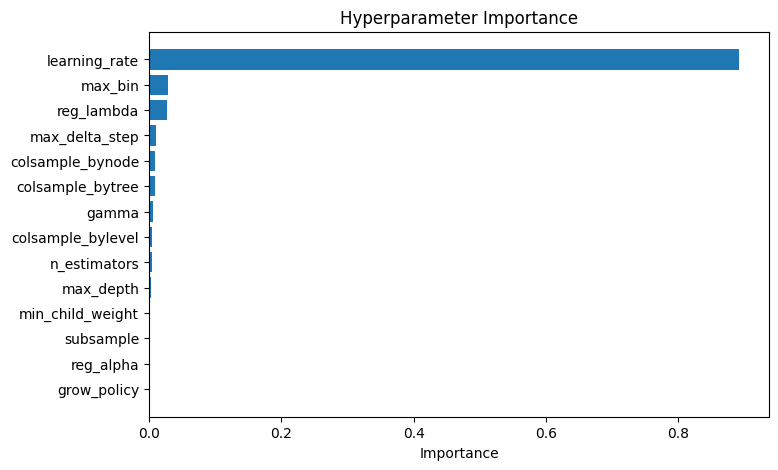

In [ ]:
TRAIN_MODE = True
TUNNING_DIR = CONFIG_PATH / "optuna_search_spaces.yaml"

optuna_spaces = load_optuna_spaces(TUNNING_DIR)

if TRAIN_MODE:
    objective = create_optuna_objective(
        model_name="XGBoost",
        X=X_train_final,
        y=y_train,
        optuna_spaces=optuna_spaces,   # <- con nombre, no posicional
        n_splits=5,
        cat_cols=None,                 # o la lista de categóricas si usas CatBoost
        random_state=RANDOM_STATE,
    )

    study_xgb = create_optuna_study(direction="minimize", random_state=RANDOM_STATE)

    study_xgb.optimize(objective, n_trials=150, show_progress_bar=True)

    print("Best RPS:", study_xgb.best_value)
    print("Best Params:", study_xgb.best_params)

    importances = optuna.importance.get_param_importances(study_xgb)

    plt.figure(figsize=(8, 5))
    plt.barh(list(importances.keys()), list(importances.values()))
    plt.xlabel("Importance")
    plt.title("Hyperparameter Importance")
    plt.gca().invert_yaxis()
    plt.show()




[I 2026-08-09 10:49:37,280] A new study created in memory with name: no-name-00e98fdf-1d02-4ee1-acfd-ab6cf4498cd0
Best trial: 0. Best value: 0.199731:   1%|          | 1/150 [00:09<22:31,  9.07s/it]

[I 2026-08-09 10:49:46,348] Trial 0 finished with value: 0.19973114208741422 and parameters: {'n_estimators': 910, 'learning_rate': 0.1683243555363146, 'num_leaves': 180, 'max_depth': 6, 'min_child_samples': 10, 'subsample': 0.7545111124170836, 'colsample_bytree': 0.6065749293421778, 'feature_fraction_bynode': 0.9662533250406801, 'reg_alpha': 0.032015824430750114, 'reg_lambda': 2.7300754773418e-08, 'min_split_gain': 0.03719519116206052, 'path_smooth': 5.918694992908618, 'max_bin': 225, 'extra_trees': True}. Best is trial 0 with value: 0.19973114208741422.


Best trial: 1. Best value: 0.185512:   1%|▏         | 2/150 [00:22<28:43, 11.65s/it]

[I 2026-08-09 10:49:59,799] Trial 1 finished with value: 0.18551180295026506 and parameters: {'n_estimators': 655, 'learning_rate': 0.014334634765318594, 'num_leaves': 17, 'max_depth': 7, 'min_child_samples': 44, 'subsample': 0.6172755083585728, 'colsample_bytree': 0.9775043967143612, 'feature_fraction_bynode': 0.6988386423867478, 'reg_alpha': 0.0005846897854895608, 'reg_lambda': 1.4635241190150147e-06, 'min_split_gain': 2.943334493867249e-06, 'path_smooth': 5.5197783922675425, 'max_bin': 400, 'extra_trees': True}. Best is trial 1 with value: 0.18551180295026506.


Best trial: 2. Best value: 0.183891:   2%|▏         | 3/150 [00:26<19:26,  7.94s/it]

...

[I 2026-08-09 11:14:44,487] Trial 147 finished with value: 0.18383215595559085 and parameters: {'n_estimators': 535, 'learning_rate': 0.014070605748705185, 'num_leaves': 213, 'max_depth': 9, 'min_child_samples': 32, 'subsample': 0.9337341868207897, 'colsample_bytree': 0.8067224639322979, 'feature_fraction_bynode': 0.6520218050519309, 'reg_alpha': 2.6481512533958142e-05, 'reg_lambda': 19.639379860975914, 'min_split_gain': 1.210700180052764e-06, 'path_smooth': 5.889931770694986, 'max_bin': 479, 'extra_trees': True}. Best is trial 37 with value: 0.18322576499404575.


Best trial: 37. Best value: 0.183226:  99%|█████████▉| 149/150 [25:12<00:08,  8.31s/it]

[I 2026-08-09 11:14:49,709] Trial 148 finished with value: 0.18495404982294406 and parameters: {'n_estimators': 255, 'learning_rate': 0.0051306535350476, 'num_leaves': 110, 'max_depth': 12, 'min_child_samples': 59, 'subsample': 0.8656764983361976, 'colsample_bytree': 0.9503420140420064, 'feature_fraction_bynode': 0.5311514308598739, 'reg_alpha': 0.0006154802385259314, 'reg_lambda': 1.890997182879068e-05, 'min_split_gain': 0.01250817347534624, 'path_smooth': 1.001065364250603, 'max_bin': 496, 'extra_trees': True}. Best is trial 37 with value: 0.18322576499404575.


Best trial: 37. Best value: 0.183226: 100%|██████████| 150/150 [25:28<00:00, 10.19s/it]


[I 2026-08-09 11:15:05,324] Trial 149 finished with value: 0.18708983521597727 and parameters: {'n_estimators': 1047, 'learning_rate': 0.01909656356917334, 'num_leaves': 175, 'max_depth': 6, 'min_child_samples': 54, 'subsample': 0.9800301149610987, 'colsample_bytree': 0.811769541007977, 'feature_fraction_bynode': 0.522514115375487, 'reg_alpha': 5.4124648161582444e-08, 'reg_lambda': 0.19927507444841808, 'min_split_gain': 0.00021559020941888307, 'path_smooth': 5.806933168240463, 'max_bin': 320, 'extra_trees': True}. Best is trial 37 with value: 0.18322576499404575.
Best RPS: 0.18322576499404575
Best Params: {'n_estimators': 434, 'learning_rate': 0.0062732720562188055, 'num_leaves': 63, 'max_depth': 12, 'min_child_samples': 42, 'subsample': 0.8177180175366877, 'colsample_bytree': 0.8180592848684569, 'feature_fraction_bynode': 0.7683900459608057, 'reg_alpha': 3.2930963366651257e-07, 'reg_lambda': 2.4450419594568896e-08, 'min_split_gain': 6.505353607800362e-07, 'path_smooth': 5.100160327683

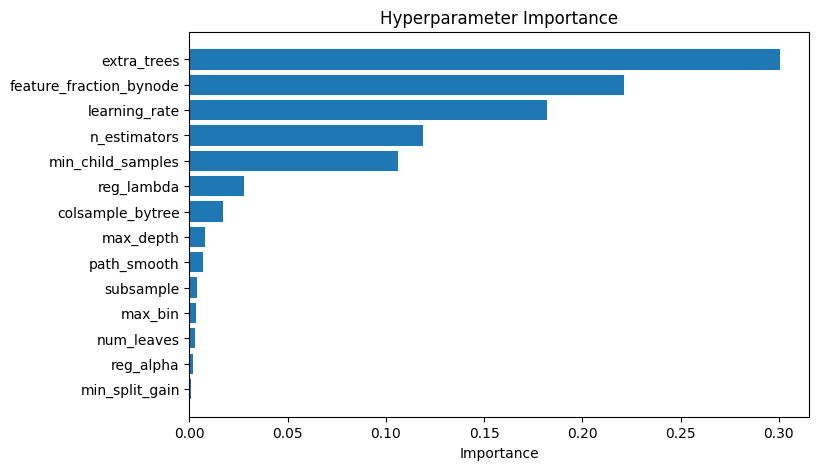

In [24]:
if TRAIN_MODE:
    objective = create_optuna_objective(
        model_name="LightGBM",
        X=X_train_final,
        y=y_train,
        optuna_spaces=optuna_spaces, 
        n_splits=5,
        cat_cols=None,
        random_state=RANDOM_STATE
    )

    study_lgbm = create_optuna_study()

    study_lgbm.optimize(
        objective,
        n_trials=150,
        show_progress_bar=True
    )

    print("Best RPS:", study_lgbm.best_value)
    print("Best Params:", study_lgbm.best_params)

    importances = get_param_importances(study_lgbm)

    plt.figure(figsize=(8,5))
    plt.barh(list(importances.keys()), list(importances.values()))
    plt.xlabel("Importance")
    plt.title("Hyperparameter Importance")
    plt.gca().invert_yaxis()

    plt.show()


[I 2026-08-09 11:15:07,929] A new study created in memory with name: no-name-f7c37e52-a828-43c0-beec-2bb349db9af0
Best trial: 0. Best value: 0.224124:   1%|          | 1/100 [01:37<2:41:13, 97.72s/it]

[I 2026-08-09 11:16:45,644] Trial 0 finished with value: 0.22412416012787717 and parameters: {'iterations': 910, 'depth': 10, 'learning_rate': 0.08290691683202742, 'l2_leaf_reg': 3.088882062609849, 'random_strength': 3.467219735882505e-08, 'bagging_temperature': 1.9313889052135447, 'border_count': 104, 'leaf_estimation_iterations': 10, 'min_data_in_leaf': 73, 'grow_policy': 'Depthwise'}. Best is trial 0 with value: 0.22412416012787717.


Best trial: 1. Best value: 0.185018:   2%|▏         | 2/100 [02:08<1:35:13, 58.30s/it]

[I 2026-08-09 11:17:16,362] Trial 1 finished with value: 0.18501775930512515 and parameters: {'iterations': 527, 'depth': 6, 'learning_rate': 0.010788831702409045, 'l2_leaf_reg': 3.2920390689562296, 'random_strength': 2.066261611090109e-06, 'bagging_temperature': 0.055570576616259526, 'border_count': 142, 'leaf_estimation_iterations': 5, 'min_data_in_leaf': 5, 'grow_policy': 'SymmetricTree'}. Best is trial 1 with value: 0.18501775930512515.


Best trial: 1. Best value: 0.185018:   3%|▎         | 3/100 [02:36<1:12:07, 44.62s/it]

...

[I 2026-08-09 12:26:15,570] Trial 97 finished with value: 0.18610713960028813 and parameters: {'iterations': 784, 'depth': 5, 'learning_rate': 0.027298698210348464, 'l2_leaf_reg': 5.102704385850653, 'random_strength': 3.013938097774091, 'bagging_temperature': 1.320925588747393, 'border_count': 104, 'leaf_estimation_iterations': 8, 'min_data_in_leaf': 59, 'grow_policy': 'SymmetricTree'}. Best is trial 48 with value: 0.18318345208649522.


Best trial: 48. Best value: 0.183183:  99%|█████████▉| 99/100 [1:12:02<00:48, 48.59s/it]

[I 2026-08-09 12:27:10,813] Trial 98 finished with value: 0.18372960783355927 and parameters: {'iterations': 633, 'depth': 7, 'learning_rate': 0.013163795640155313, 'l2_leaf_reg': 18.21868165520338, 'random_strength': 4.940957127234261, 'bagging_temperature': 0.8546476196330391, 'border_count': 110, 'leaf_estimation_iterations': 8, 'min_data_in_leaf': 42, 'grow_policy': 'SymmetricTree'}. Best is trial 48 with value: 0.18318345208649522.


Best trial: 48. Best value: 0.183183: 100%|██████████| 100/100 [1:12:19<00:00, 43.39s/it]


[I 2026-08-09 12:27:27,064] Trial 99 finished with value: 0.18372764249599643 and parameters: {'iterations': 309, 'depth': 5, 'learning_rate': 0.014270983194218208, 'l2_leaf_reg': 28.531207047098103, 'random_strength': 0.4827363270859227, 'bagging_temperature': 0.43279828032286277, 'border_count': 100, 'leaf_estimation_iterations': 5, 'min_data_in_leaf': 49, 'grow_policy': 'Depthwise'}. Best is trial 48 with value: 0.18318345208649522.
Best RPS: 0.18318345208649522
Best Params: {'iterations': 1064, 'depth': 5, 'learning_rate': 0.006280014077818713, 'l2_leaf_reg': 8.657039401617709, 'random_strength': 8.03671022493703, 'bagging_temperature': 1.3139613208134444, 'border_count': 157, 'leaf_estimation_iterations': 2, 'min_data_in_leaf': 34, 'grow_policy': 'SymmetricTree'}


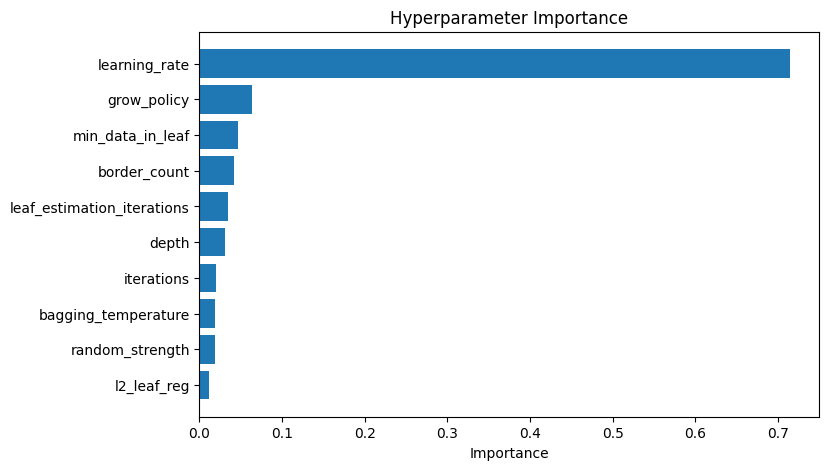

In [25]:
if TRAIN_MODE:
    objective_CAT = create_optuna_objective(
        model_name="CatBoost",
        X=X_train_final,
        y=y_train,
        optuna_spaces=optuna_spaces, 
        n_splits=5,
        cat_cols=None,
        random_state=RANDOM_STATE
    )

    study_CAT = create_optuna_study()

    study_CAT.optimize(
        objective_CAT,
        n_trials=100,
        show_progress_bar=True
    )

    print("Best RPS:", study_CAT.best_value)
    print("Best Params:", study_CAT.best_params)


    importances = get_param_importances(study_CAT)

    plt.figure(figsize=(8,5))
    plt.barh(list(importances.keys()), list(importances.values()))
    plt.xlabel("Importance")
    plt.title("Hyperparameter Importance")
    plt.gca().invert_yaxis()

    plt.show()


[I 2026-08-09 13:08:18,776] A new study created in memory with name: no-name-fff3aee4-b487-43ff-b87c-2337a633e617
Best trial: 0. Best value: 0.183421:   1%|          | 1/150 [00:08<21:18,  8.58s/it]

[I 2026-08-09 13:08:27,353] Trial 0 finished with value: 0.18342105050186314 and parameters: {'bootstrap': False, 'n_estimators': 886, 'max_depth': 13, 'min_samples_split': 3, 'min_samples_leaf': 8, 'max_features': 'log2'}. Best is trial 0 with value: 0.18342105050186314.


Best trial: 1. Best value: 0.183279:   1%|▏         | 2/150 [00:14<17:54,  7.26s/it]

[I 2026-08-09 13:08:33,687] Trial 1 finished with value: 0.18327918544450084 and parameters: {'bootstrap': True, 'n_estimators': 452, 'max_depth': 13, 'min_samples_split': 7, 'min_samples_leaf': 8, 'max_features': 0.8, 'max_samples': 0.521594385448216}. Best is trial 1 with value: 0.18327918544450084.


Best trial: 1. Best value: 0.183279:   2%|▏         | 3/150 [00:24<20:19,  8.30s/it]

...

[I 2026-08-09 13:35:00,831] Trial 147 finished with value: 0.1831070799621112 and parameters: {'bootstrap': True, 'n_estimators': 1100, 'max_depth': 19, 'min_samples_split': 24, 'min_samples_leaf': 10, 'max_features': 0.8, 'max_samples': 0.9013342719853503}. Best is trial 134 with value: 0.18301708387873306.


Best trial: 134. Best value: 0.183017:  99%|█████████▉| 149/150 [26:59<00:14, 14.84s/it]

[I 2026-08-09 13:35:18,256] Trial 148 finished with value: 0.18315123890465207 and parameters: {'bootstrap': True, 'n_estimators': 1156, 'max_depth': 18, 'min_samples_split': 25, 'min_samples_leaf': 7, 'max_features': 0.8, 'max_samples': 0.9191798667344195}. Best is trial 134 with value: 0.18301708387873306.


Best trial: 134. Best value: 0.183017: 100%|██████████| 150/150 [27:10<00:00, 10.87s/it]


[I 2026-08-09 13:35:29,203] Trial 149 finished with value: 0.18343732561735476 and parameters: {'bootstrap': True, 'n_estimators': 757, 'max_depth': 16, 'min_samples_split': 29, 'min_samples_leaf': 16, 'max_features': 0.5, 'max_samples': 0.9185769250653741}. Best is trial 134 with value: 0.18301708387873306.
Best RPS: 0.18301708387873306
Best Params: {'bootstrap': True, 'n_estimators': 975, 'max_depth': 15, 'min_samples_split': 25, 'min_samples_leaf': 6, 'max_features': 0.8, 'max_samples': 0.9316140297844117}


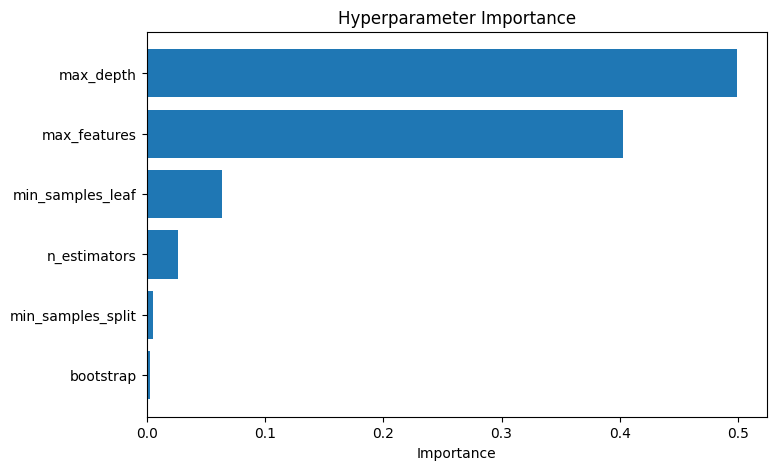

In [26]:
if TRAIN_MODE:
    objective_extra = create_optuna_objective(
        model_name="extra",
        X=X_train_final,
        y=y_train,
        optuna_spaces=optuna_spaces, 
        n_splits=5,
        cat_cols=None,
        random_state=RANDOM_STATE
    )

    study_extra = create_optuna_study()

    study_extra.optimize(
        objective_extra,
        n_trials=150,
        show_progress_bar=True
    )

    print("Best RPS:", study_extra.best_value)
    print("Best Params:", study_extra.best_params)


    importances = get_param_importances(study_extra)

    plt.figure(figsize=(8,5))
    plt.barh(list(importances.keys()), list(importances.values()))
    plt.xlabel("Importance")
    plt.title("Hyperparameter Importance")
    plt.gca().invert_yaxis()

    plt.show()

[I 2026-08-09 13:36:30,044] A new study created in memory with name: no-name-710a8e9b-869c-4a78-832e-adcb2c296b8c
Best trial: 0. Best value: 0.183691:   0%|          | 1/250 [00:40<2:48:04, 40.50s/it]

[I 2026-08-09 13:37:10,543] Trial 0 finished with value: 0.18369130887611373 and parameters: {'penalty': 'l2', 'C': 0.004549452186429166}. Best is trial 0 with value: 0.18369130887611373.


Best trial: 0. Best value: 0.183691:   1%|          | 2/250 [01:04<2:07:37, 30.88s/it]

[I 2026-08-09 13:37:34,687] Trial 1 finished with value: 0.1844005924792668 and parameters: {'penalty': 'l2', 'C': 4.5976218744590405}. Best is trial 0 with value: 0.18369130887611373.


Best trial: 0. Best value: 0.183691:   1%|          | 3/250 [01:05<1:10:08, 17.04s/it]

...

[I 2026-08-09 13:40:03,684] Trial 247 finished with value: 0.18354248500992615 and parameters: {'penalty': 'elasticnet', 'C': 0.024351398756960182, 'l1_ratio': 0.41360515899399325}. Best is trial 247 with value: 0.18354248500992615.


Best trial: 247. Best value: 0.183542: 100%|█████████▉| 249/250 [03:34<00:00,  2.43it/s]

[I 2026-08-09 13:40:04,064] Trial 248 finished with value: 0.18468996564329343 and parameters: {'penalty': 'l1', 'C': 0.013558903039994668}. Best is trial 247 with value: 0.18354248500992615.


Best trial: 247. Best value: 0.183542: 100%|██████████| 250/250 [03:34<00:00,  1.17it/s]


[I 2026-08-09 13:40:04,456] Trial 249 finished with value: 0.1835569108609312 and parameters: {'penalty': 'elasticnet', 'C': 0.02779400796915242, 'l1_ratio': 0.5941492663923039}. Best is trial 247 with value: 0.18354248500992615.
Best RPS: 0.18354248500992615
Best Params: {'penalty': 'elasticnet', 'C': 0.024351398756960182, 'l1_ratio': 0.41360515899399325}


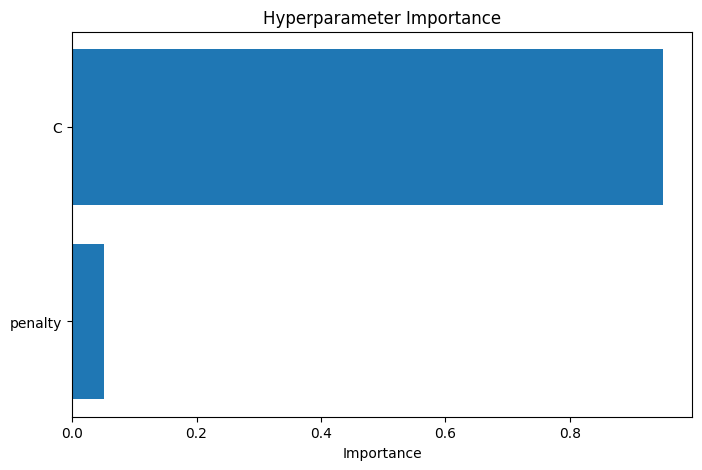

In [27]:
if TRAIN_MODE:
    objective_log = create_optuna_objective(
        model_name="Logistic",
        X=X_train_final,
        y=y_train,
        optuna_spaces=optuna_spaces, 
        n_splits=5,
        cat_cols=None,
        random_state=RANDOM_STATE
    )

    study_log = create_optuna_study()

    study_log.optimize(
        objective_log,
        n_trials=250,
        show_progress_bar=True
    )


    print("Best RPS:", study_log.best_value)
    print("Best Params:", study_log.best_params)

    importances = get_param_importances(study_log)

    plt.figure(figsize=(8,5))
    plt.barh(list(importances.keys()), list(importances.values()))
    plt.xlabel("Importance")
    plt.title("Hyperparameter Importance")
    plt.gca().invert_yaxis()

    plt.show()


In [31]:
# 1. Definir el mapeo con tus objetos de Optuna ya entrenados
studies_dict: Dict[str, optuna.Study] = {
    "LogisticRegression": study_log,
    "ExtraTrees": study_extra,
    "LightGBM": study_lgbm,
    "CatBoost": study_CAT,
    "XGBoost": study_xgb,  
}

export_optuna_tuning_results(
    studies_dict,CONFIG_PATH, METRICS_DIR
)


 EXPORTANDO RESULTADOS DE OPTUNA Y CONFIGURACIONES YAML
 [YAML] Parámetros guardados para 'LogisticRegression' -> best_params_logisticregression.yaml
 [YAML] Parámetros guardados para 'ExtraTrees' -> best_params_extratrees.yaml
 [YAML] Parámetros guardados para 'LightGBM' -> best_params_lightgbm.yaml
 [YAML] Parámetros guardados para 'CatBoost' -> best_params_catboost.yaml
 [YAML] Parámetros guardados para 'XGBoost' -> best_params_xgboost.yaml
------------------------------------------------------------
[EXITO] Resumen de validación guardado en JSON:
 -> c:\Users\javie\OneDrive\Escritorio\ModelosProbabilisticos\EnvOficial\outputs\clubs\model_metrics\tunned_models_validation_results.json



### Checkpoint on YAML hypertunned models

In [35]:
from src.hypertunning.hypertunning import load_best_params

BEST_PARAMS_DICT = load_best_params(CONFIG_PATH)

val_results = {}

for model_name in BEST_PARAMS_DICT.keys():
    print(f"\nTraining {model_name} with frozen parameters...")

    res = train_and_evaluate_hardcoded(
        model_name=model_name,
        X_train=X_train_final,
        y_train=y_train,
        X_val=X_val_final,
        y_val=y_val,
        cat_cols=None,
        best_params_dict=BEST_PARAMS_DICT,
        RANDOM_STATE=RANDOM_STATE,
    )

    val_results[model_name] = res
    print(f"{model_name} VAL RPS: {res['val_rps']:.5f}")

 [OK] CatBoost: 10 parametros <- best_params_catboost.yaml
 [OK] ExtraTrees: 7 parametros <- best_params_extratrees.yaml
 [OK] LightGBM: 14 parametros <- best_params_lightgbm.yaml
 [OK] LogisticRegression: 4 parametros <- best_params_logisticregression.yaml
 [OK] XGBoost: 14 parametros <- best_params_xgboost.yaml

Training CatBoost with frozen parameters...
CatBoost VAL RPS: 0.18134

Training ExtraTrees with frozen parameters...
ExtraTrees VAL RPS: 0.17977

Training LightGBM with frozen parameters...
LightGBM VAL RPS: 0.18004

Training LogisticRegression with frozen parameters...
LogisticRegression VAL RPS: 0.18203

Training XGBoost with frozen parameters...
XGBoost VAL RPS: 0.18112


### Error Analysis

Metadata loaded. Columns available for analysis: ['match_id', 'match_datetime_utc', 'season_id', 'home_team_id', 'away_team_id', 'home_score', 'away_score', 'home_venue_id', 'home_referee_id', 'home_macro_rolling_goals']...
STARTING ERROR ANALYSIS PIPELINE...
Validation Set Size: 2369 matches

TEST 6: Consensus & Ensemble Potential
GOAL: Check if models agree. Low correlation = High Ensemble Potential.


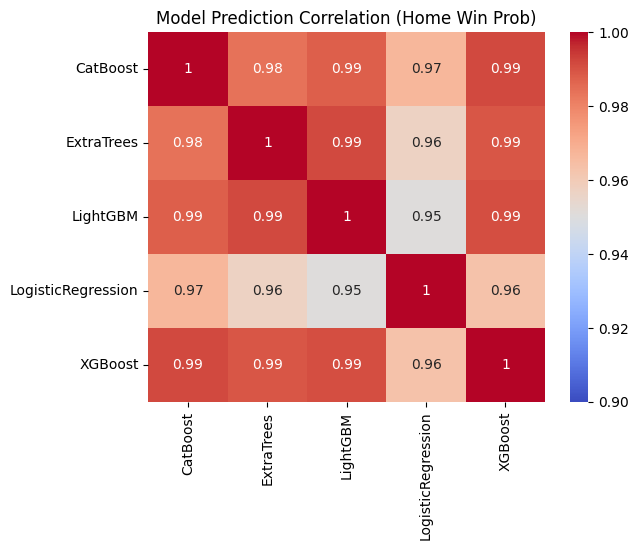

Average Correlation: 0.9772

TEST 1: Reliability & Calibration Analysis
GOAL: Determine if '70% confidence' actually means 70% win rate.
[CatBoost] Home Win Brier Score: 0.1916
[ExtraTrees] Home Win Brier Score: 0.1890
[LightGBM] Home Win Brier Score: 0.1894
[LogisticRegression] Home Win Brier Score: 0.1939
[XGBoost] Home Win Brier Score: 0.1910


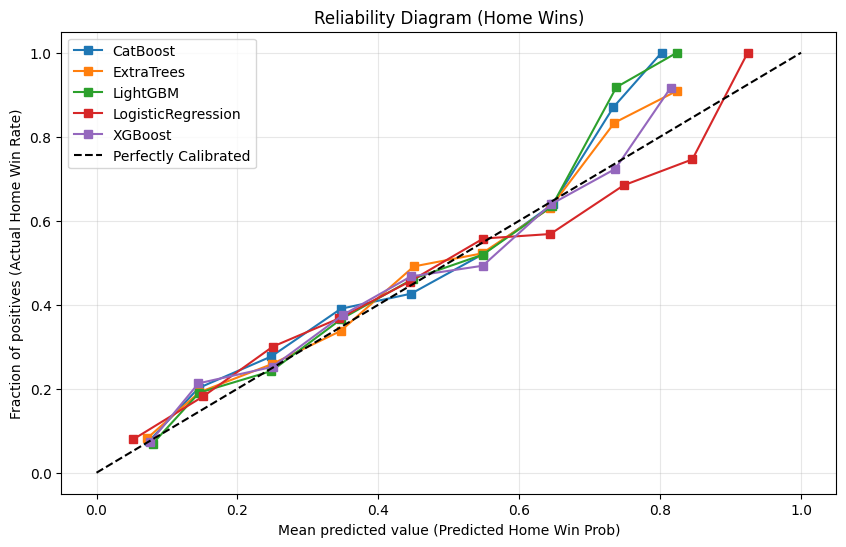


TEST 3: Tournament Segmented Performance
GOAL: Identify which leagues/cups we fail to predict.
Analysis using model: CatBoost
                         RPS  Count
tournament                         
community-shield    0.392609      1
coupe_de_france     0.225576    149
bundesliga          0.190476    306
premier-league      0.189532    380
italian-supercup    0.185982      6
uefa-europa-league  0.181488    189
serie-a             0.181182    380
laliga              0.178280    380
copa-del-rey        0.175772     17
fa-cup              0.173574     15

TEST 4: Data Blindspots (Feature Slicing)
GOAL: Find non-linear weaknesses in specific scenarios.


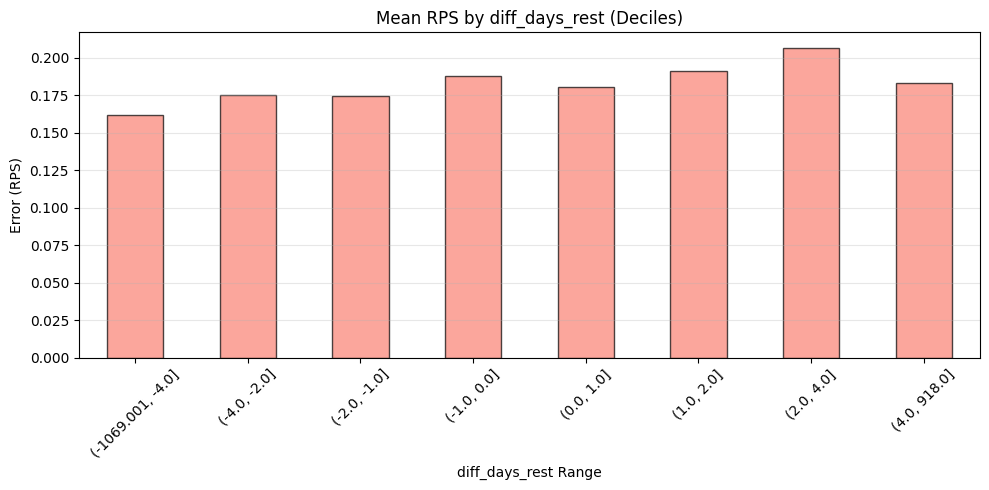

-> Plotted error distribution for diff_days_rest


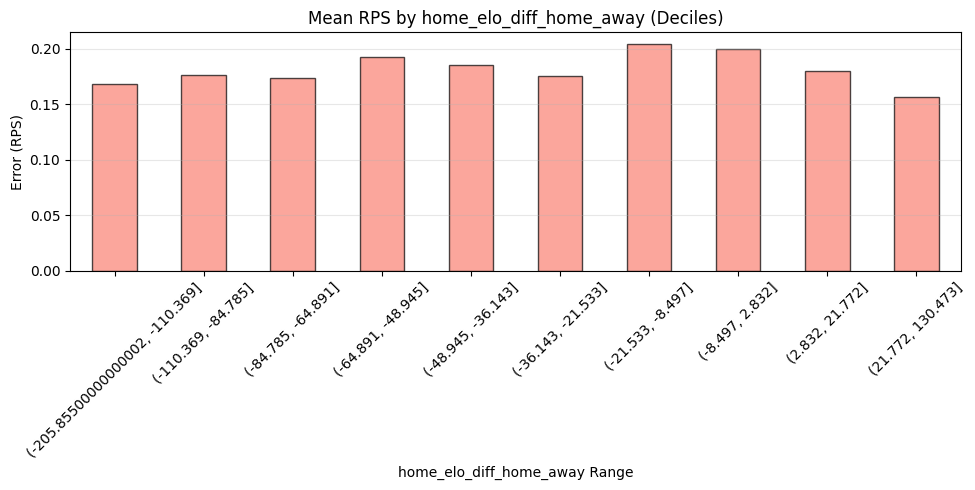

-> Plotted error distribution for home_elo_diff_home_away


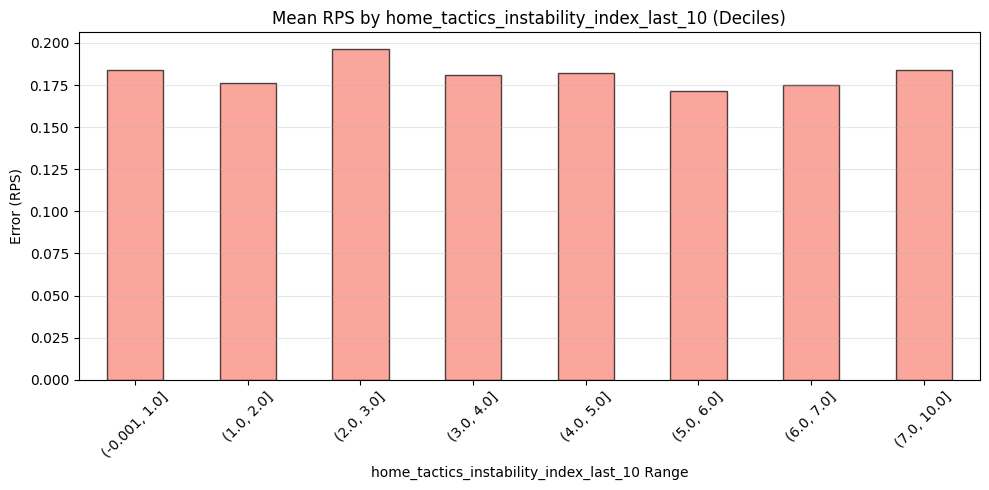

-> Plotted error distribution for home_tactics_instability_index_last_10

TEST 5: Expected Calibration Error by Category
GOAL: Measure calibration quality for each model within each category.

Top 20 worst calibrated segments (MacroAvg):


,tournament,Model,Outcome,Samples,ECE
102,coupe_de_france,LogisticRegression,MacroAvg,149,0.148918
6,coupe_de_france,CatBoost,MacroAvg,149,0.112064
134,coupe_de_france,XGBoost,MacroAvg,149,0.088971
26,uefa-champions-league,CatBoost,MacroAvg,189,0.080628
70,coupe_de_france,LightGBM,MacroAvg,149,0.080133
122,uefa-champions-league,LogisticRegression,MacroAvg,189,0.077373
38,coupe_de_france,ExtraTrees,MacroAvg,149,0.074818
94,uefa-europa-league,LightGBM,MacroAvg,189,0.074130
154,uefa-champions-league,XGBoost,MacroAvg,189,0.073205
58,uefa-champions-league,ExtraTrees,MacroAvg,189,0.072083


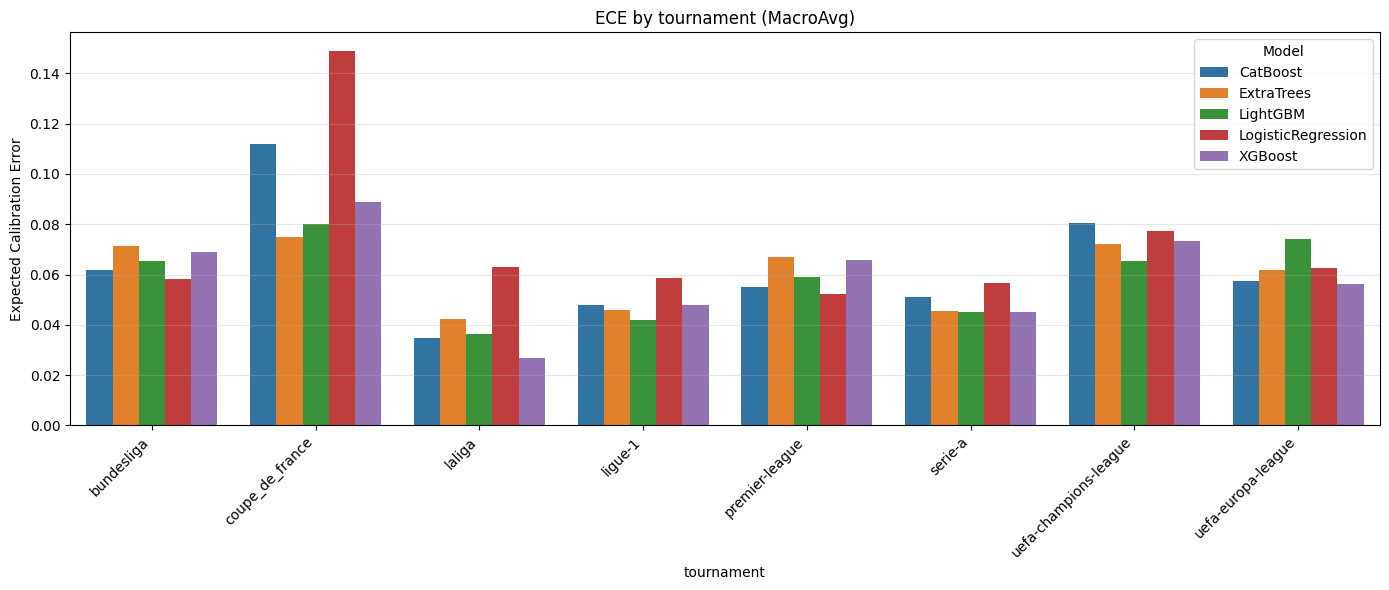


PIPELINE COMPLETE


In [36]:
model_predictions = {}

for name, result in val_results.items():

    if not isinstance(result, dict):
        raise TypeError(f"{name} result is not a dict")

    if "val_probs" not in result:
        raise KeyError(f"{name} missing val_probs")

    probs = result["val_probs"]

    if not isinstance(probs, np.ndarray):
        raise TypeError(f"{name} val_probs is not ndarray, got {type(probs)}")

    model_predictions[name] = probs

val_metadata_df = df.loc[X_val_final.index].copy()

# OPTIONAL: Sanity check to ensure lengths match
assert len(val_metadata_df) == len(list(model_predictions.values())[0]), \
    "Error: Metadata length does not match prediction length!"

print(f"Metadata loaded. Columns available for analysis: {val_metadata_df.columns.tolist()[:10]}...")

# ==============================================================================
# STEP 3: Run the Analysis Pipeline
# ==============================================================================
analyzer = SoccerModelErrorAnalyzer(
    val_df=val_metadata_df,
    y_true=y_val,
    model_preds_dict=model_predictions,
    outcomes_order=['D', 'W', 'L']
)
# Execute the plan
analyzer.run_pipeline()



### Error Interceptions

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from sklearn.calibration import calibration_curve
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# 0. SETUP: Use only VAL set data (NO leakage)
# ============================================================================

# Extract predictions from previous step
models = ['CatBoost', 'XGBoost', 'LightGBM', 'ExtraTrees', 'LogisticRegression']
val_probs = {name: val_results[name]['val_probs'] for name in models}
val_preds = {name: np.argmax(val_results[name]['val_probs'], axis=1) for name in models}

# True outcomes (0=Draw, 1=Home, 2=Away)
y_true = y_val.values

# ============================================================================
# 1. STRATIFIED FAILURES: Where do models disagree?
# ============================================================================

print("="*70)
print("1. DISAGREEMENT ANALYSIS (Hard vs Easy Matches)")
print("="*70)

# Calculate prediction entropy (uncertainty) per model
def calc_entropy(probs):
    """Calculate prediction entropy: higher = more uncertain"""
    return -np.sum(probs * np.log(probs + 1e-10), axis=1)

uncertainty = {name: calc_entropy(val_probs[name]) for name in models}

# Identify hard matches: where models disagree on winner
winners = np.array([np.argmax(val_probs[m], axis=1) for m in models])
disagreement_mask = np.array([len(set(winners[:, i])) > 1 for i in range(len(y_true))])
unanimous_mask = ~disagreement_mask

print(f"Matches with model disagreement: {disagreement_mask.sum()} ({disagreement_mask.mean()*100:.1f}%)")
print(f"Unanimous predictions: {unanimous_mask.sum()} ({unanimous_mask.mean()*100:.1f}%)")

# Performance on hard vs easy matches
for name in models:
    hard_rps = evaluate_model(y_true[disagreement_mask], val_probs[name][disagreement_mask])['rps']
    easy_rps = evaluate_model(y_true[unanimous_mask], val_probs[name][unanimous_mask])['rps']
    print(f"{name:12} | Hard RPS: {hard_rps:.4f} | Easy RPS: {easy_rps:.4f} | Gap: {hard_rps-easy_rps:+.4f}")

# Check if models fail on same matches
failures = {}
for name in models:
    pred_class = np.argmax(val_probs[name], axis=1)
    failures[name] = (pred_class != y_true)

failure_overlap = np.zeros((len(models), len(models)))
for i, m1 in enumerate(models):
    for j, m2 in enumerate(models):
        # Jaccard similarity of failure sets
        intersection = np.sum(failures[m1] & failures[m2])
        union = np.sum(failures[m1] | failures[m2])
        failure_overlap[i, j] = intersection / union if union > 0 else 0

failure_df = pd.DataFrame(failure_overlap, index=models, columns=models)
print("\nFailure Overlap (Jaccard Index) - Higher = models fail on same matches:")
print(failure_df.round(3))





1. DISAGREEMENT ANALYSIS (Hard vs Easy Matches)
Matches with model disagreement: 375 (15.8%)
Unanimous predictions: 1994 (84.2%)
CatBoost     | Hard RPS: 0.2186 | Easy RPS: 0.1743 | Gap: +0.0443
XGBoost      | Hard RPS: 0.2161 | Easy RPS: 0.1745 | Gap: +0.0415
LightGBM     | Hard RPS: 0.2133 | Easy RPS: 0.1738 | Gap: +0.0396
ExtraTrees   | Hard RPS: 0.2120 | Easy RPS: 0.1737 | Gap: +0.0383
LogisticRegression | Hard RPS: 0.2205 | Easy RPS: 0.1748 | Gap: +0.0457

Failure Overlap (Jaccard Index) - Higher = models fail on same matches:
                    CatBoost  XGBoost  LightGBM  ExtraTrees  \
CatBoost               1.000    0.915     0.916       0.907   
XGBoost                0.915    1.000     0.932       0.901   
LightGBM               0.916    0.932     1.000       0.933   
ExtraTrees             0.907    0.901     0.933       1.000   
LogisticRegression     0.850    0.801     0.803       0.812   

                    LogisticRegression  
CatBoost                         0.850  
X

### Models Correlations

In [38]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr

# Stack validation probabilities: shape (n_samples, n_models, n_classes)
val_probs = np.stack([
    val_results['CatBoost']['val_probs'],
    val_results['XGBoost']['val_probs'],      
    val_results['LightGBM']['val_probs'],
    val_results['ExtraTrees']['val_probs'],
    val_results['LogisticRegression']['val_probs'],
], axis=1)

# Calculate correlation matrices per class
models = ['CatBoost', 'XGBoost', 'LightGBM', 'ExtraTrees', 'LogisticRegression']
n_models = len(models)

print("="*60)
print("PREDICTION CORRELATION ANALYSIS (Validation Set)")
print("="*60)

for class_idx, class_name in enumerate(['Draw', 'Home', 'Away']):
    print(f"\n{class_name} Win Probability Correlations:")
    corr_matrix = np.zeros((n_models, n_models))

    for i in range(n_models):
        for j in range(n_models):
            # Pearson correlation of predicted probabilities for this class
            corr, _ = pearsonr(val_probs[:, i, class_idx], val_probs[:, j, class_idx])
            corr_matrix[i, j] = corr

    corr_df = pd.DataFrame(corr_matrix, index=models, columns=models)
    print(corr_df.round(3))

    # Check average correlation (lower = more diversity)
    avg_corr = np.mean(corr_matrix[np.triu_indices(n_models, k=1)])
    print(f"Average pairwise correlation: {avg_corr:.3f}")

# Check rank correlation (Spearman) - important for RPS since it depends on ordering
print("\n" + "="*60)
print("RANK CORRELATION (Spearman) - Key for RPS Improvement")
print("="*60)

# For RPS, we care about the ranking of Home/Draw/Away within each match
# High rank correlation = models agree on which outcome is most likely
rank_agreement = np.zeros((n_models, n_models))
for i in range(n_models):
    for j in range(n_models):
        # Correlation of predicted class ranks per sample
        ranks_i = np.argsort(np.argsort(val_probs[:, i], axis=1), axis=1)
        ranks_j = np.argsort(np.argsort(val_probs[:, j], axis=1), axis=1)
        # Average correlation across samples
        corrs = [spearmanr(ranks_i[k], ranks_j[k])[0] for k in range(len(ranks_i))]
        rank_agreement[i, j] = np.mean(corrs)

rank_df = pd.DataFrame(rank_agreement, index=models, columns=models)
print(rank_df.round(3))

# Diversity Score: Lower off-diagonal = better ensemble potential
diversity_score = 1 - np.mean(rank_agreement[np.triu_indices(n_models, k=1)])
print(f"\nEnsemble Diversity Score: {diversity_score:.3f}")
print("Interpretation: >0.15 high diversity, <0.05 low diversity (diminishing returns)")

PREDICTION CORRELATION ANALYSIS (Validation Set)

Draw Win Probability Correlations:
                    CatBoost  XGBoost  LightGBM  ExtraTrees  \
CatBoost               1.000    0.968     0.974       0.953   
XGBoost                0.968    1.000     0.967       0.941   
LightGBM               0.974    0.967     1.000       0.965   
ExtraTrees             0.953    0.941     0.965       1.000   
LogisticRegression     0.914    0.904     0.890       0.875   

                    LogisticRegression  
CatBoost                         0.914  
XGBoost                          0.904  
LightGBM                         0.890  
ExtraTrees                       0.875  
LogisticRegression               1.000  
Average pairwise correlation: 0.935

Home Win Probability Correlations:
                    CatBoost  XGBoost  LightGBM  ExtraTrees  \
CatBoost               1.000    0.991     0.989       0.984   
XGBoost                0.991    1.000     0.993       0.986   
LightGBM               0.989 

### Calibration Problem?


2. CALIBRATION ANALYSIS


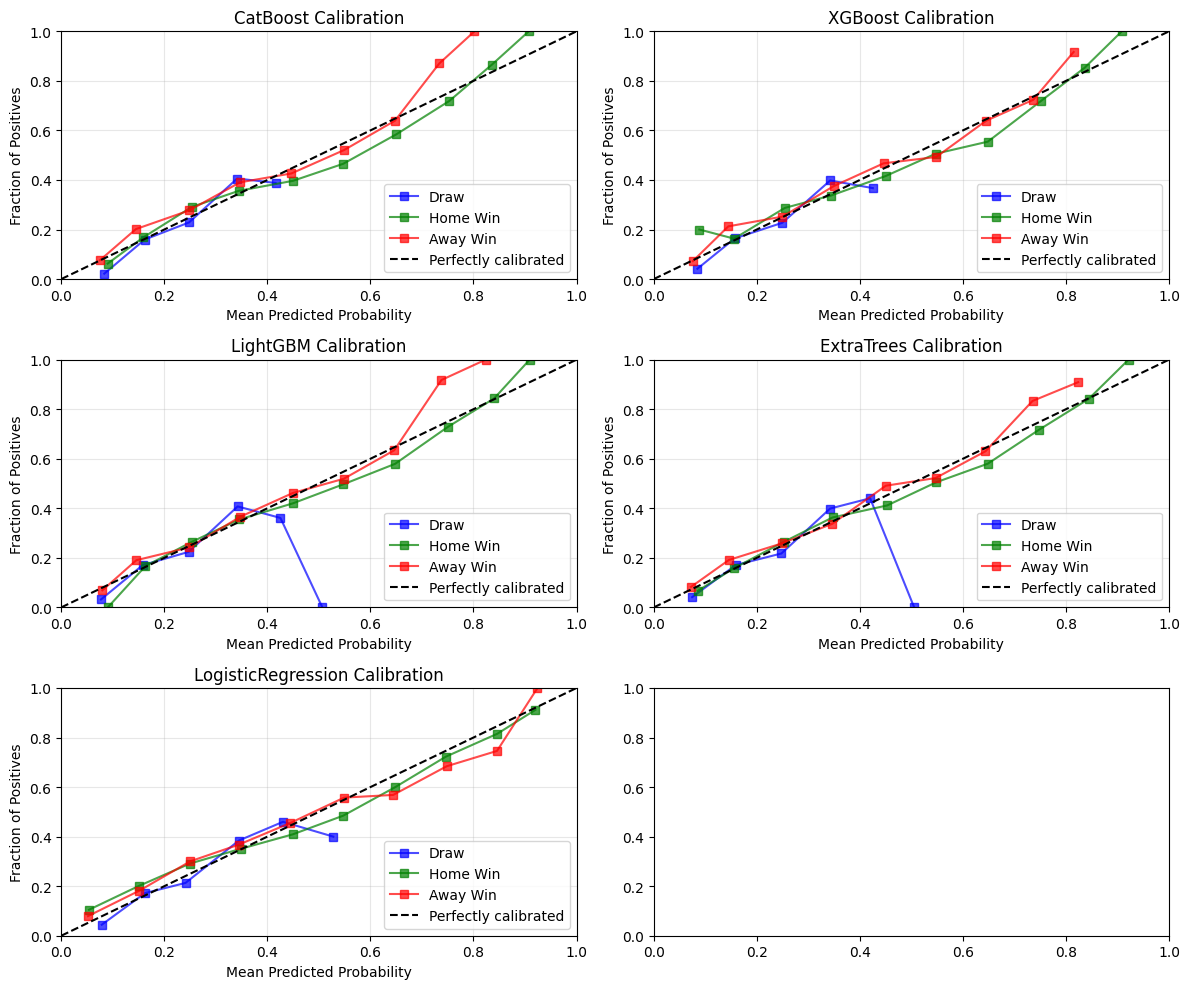

In [39]:
print("\n" + "="*70)
print("2. CALIBRATION ANALYSIS")
print("="*70)

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, name in enumerate(models):
    ax = axes[idx]

    # For each outcome (H/D/A), plot calibration curve
    outcomes = ['Draw', 'Home Win', 'Away Win']
    colors = ['blue', 'green', 'red']

    for outcome_idx, (outcome, color) in enumerate(zip(outcomes, colors)):
        y_true_binary = (y_true == outcome_idx).astype(int)
        prob_pred = val_results[name]["val_probs"][:, outcome_idx]

        # Only plot if we have enough variance
        if prob_pred.std() > 0.01:
            fraction_of_positives, mean_predicted_value = calibration_curve(
                y_true_binary, prob_pred, n_bins=10, strategy='uniform'
            )

            ax.plot(mean_predicted_value, fraction_of_positives, "s-",
                   label=outcome, color=color, alpha=0.7)

    # Perfect calibration line
    ax.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
    ax.set_xlabel("Mean Predicted Probability")
    ax.set_ylabel("Fraction of Positives")
    ax.set_title(f"{name} Calibration")
    ax.legend(loc="lower right")
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(METRICS_DIR / 'calibration_analysis.png', dpi=150, bbox_inches='tight')
plt.show()



### Odds Based Strength

In [40]:
print("\n" + "="*70)
print("3. PERFORMANCE BY MATCH DIFFICULTY (Odds-based)")
print("="*70)

if 'odds_home' in X_val.columns and 'odds_away' in X_val.columns:
    # Convert odds to implied probabilities (with margin correction)
    implied_home = 1 / X_val['odds_home'].values
    implied_away = 1 / X_val['odds_away'].values
    # Favorite strength = max implied probability
    favorite_strength = np.maximum(implied_home, implied_away)
else:
    # Fallback: use max predicted probability across models as proxy
    avg_probs = np.mean(
    [val_results[m]["val_probs"] for m in models],
    axis=0
)
    favorite_strength = np.max(avg_probs, axis=1)

# Create buckets
buckets = pd.qcut(favorite_strength, q=5, labels=['Coin Flip', 'Slight Fav', 'Moderate Fav', 'Strong Fav', 'Heavy Fav'])
bucket_performance = {}

for name in models:
    bucket_rps = []
    for bucket in ['Coin Flip', 'Slight Fav', 'Moderate Fav', 'Strong Fav', 'Heavy Fav']:
        mask = buckets == bucket
        if mask.sum() > 0:
            rps = evaluate_model(
                y_true[mask],
                val_results[name]["val_probs"][mask]
            )['rps']
            bucket_rps.append(rps)
        else:
            bucket_rps.append(np.nan)
    bucket_performance[name] = bucket_rps

bucket_df = pd.DataFrame(bucket_performance,
                        index=['Coin Flip', 'Slight Fav', 'Moderate Fav', 'Strong Fav', 'Heavy Fav'])
print("\nRPS by Match Difficulty (lower = better):")
print(bucket_df.round(4))

# Check if any model dominates specific buckets
best_per_bucket = bucket_df.idxmin(axis=1)
print(f"\nBest model per bucket:\n{best_per_bucket}")

if best_per_bucket.nunique() > 1:
    print("  Different models excel in different scenarios. Weighted ensemble recommended.")
else:
    print(f"   {best_per_bucket.iloc[0]} dominates all buckets. Single model may suffice.")


3. PERFORMANCE BY MATCH DIFFICULTY (Odds-based)

RPS by Match Difficulty (lower = better):
              CatBoost  XGBoost  LightGBM  ExtraTrees  LogisticRegression
Coin Flip       0.2132   0.2115    0.2092      0.2082              0.2152
Slight Fav      0.2117   0.2114    0.2113      0.2119              0.2108
Moderate Fav    0.2000   0.2010    0.1995      0.1980              0.2011
Strong Fav      0.1758   0.1765    0.1754      0.1755              0.1768
Heavy Fav       0.1059   0.1053    0.1048      0.1053              0.1063

Best model per bucket:
Coin Flip               ExtraTrees
Slight Fav      LogisticRegression
Moderate Fav            ExtraTrees
Strong Fav                LightGBM
Heavy Fav                 LightGBM
dtype: object
  Different models excel in different scenarios. Weighted ensemble recommended.


### Temporal Analysis

In [41]:
df_prepared['match_datetime_utc'] = pd.to_datetime(
    df_prepared['match_datetime_utc'],
    format='ISO8601'
)

df_prepared['week'] = df_prepared['match_datetime_utc'].dt.isocalendar().week

df_prepared['month'] = df_prepared['match_datetime_utc'].dt.month

df_prepared['quarter'] = df_prepared['match_datetime_utc'].dt.quarter


variables = list(X_val.columns) + ['quarter']


### Bias Analysis

In [42]:
print("\n" + "="*70)
print("5. SYSTEMATIC BIAS ANALYSIS")
print("="*70)

draw_matches= y_true == 0
home_matches = y_true == 1
away_matches = y_true == 2

print("\nRPS by Actual Result:")

bias_report = {}

for name in models:

    probs = val_results[name]["val_probs"]

    home_rps = evaluate_model(y_true[home_matches], probs[home_matches])['rps']
    draw_rps = evaluate_model(y_true[draw_matches], probs[draw_matches])['rps']
    away_rps = evaluate_model(y_true[away_matches], probs[away_matches])['rps']

    bias_report[name] = {
        'Home': home_rps,
        'Draw': draw_rps,
        'Away': away_rps
    }

    print(f"{name:12} | Home: {home_rps:.4f} | Draw: {draw_rps:.4f} | Away: {away_rps:.4f}")

bias_df = pd.DataFrame(bias_report).T

# ---------------------------------------------------
# Favorite vs Underdog Bias
# ---------------------------------------------------

print("\nAccuracy when predicting Favorite (prob > 0.5) vs Underdog:")

for name in models:

    pred_probs = val_results[name]["val_probs"]

    max_probs = np.max(pred_probs, axis=1)
    pred_classes = np.argmax(pred_probs, axis=1)

    high_conf = max_probs > 0.5

    if high_conf.sum() > 0:

        acc_high = (pred_classes[high_conf] == y_true[high_conf]).mean()
        acc_low = (pred_classes[~high_conf] == y_true[~high_conf]).mean()

        print(f"{name:12} | High Conf (>0.5): {acc_high:.3f} | "
              f"Low Conf: {acc_low:.3f} | Gap: {acc_high-acc_low:+.3f}")


5. SYSTEMATIC BIAS ANALYSIS

RPS by Actual Result:
CatBoost     | Home: 0.0698 | Draw: 0.3369 | Away: 0.2144
XGBoost      | Home: 0.0706 | Draw: 0.3391 | Away: 0.2112
LightGBM     | Home: 0.0701 | Draw: 0.3378 | Away: 0.2096
ExtraTrees   | Home: 0.0697 | Draw: 0.3335 | Away: 0.2122
LogisticRegression | Home: 0.0730 | Draw: 0.3342 | Away: 0.2143

Accuracy when predicting Favorite (prob > 0.5) vs Underdog:
CatBoost     | High Conf (>0.5): 0.618 | Low Conf: 0.417 | Gap: +0.200
XGBoost      | High Conf (>0.5): 0.622 | Low Conf: 0.430 | Gap: +0.193
LightGBM     | High Conf (>0.5): 0.627 | Low Conf: 0.435 | Gap: +0.192
ExtraTrees   | High Conf (>0.5): 0.626 | Low Conf: 0.442 | Gap: +0.185
LogisticRegression | High Conf (>0.5): 0.622 | Low Conf: 0.429 | Gap: +0.193


In [45]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import log_loss, accuracy_score
from sklearn.model_selection import TimeSeriesSplit
import numpy as np
import pandas as pd


# =============================================================================
# 1. PREPARE META FEATURES
# =============================================================================
model_names = ['CatBoost', 'XGBoost', 'LightGBM', 'ExtraTrees', 'LogisticRegression']

val_prob_dict = {
    name: val_results[name]['val_probs']
    for name in model_names
}

y_meta = y_val.values

# =============================================================================
# 2. BASELINE ENSEMBLES
# =============================================================================
print("\n" + "=" * 60)
print("BASELINE ENSEMBLES")
print("=" * 60)

stacked_probs = np.stack(
    [val_prob_dict[m] for m in model_names],
    axis=0
)

baselines = {
    'Simple_Average': np.mean(stacked_probs, axis=0),
    'Median_Ensemble': np.median(stacked_probs, axis=0),
    'Best_Single_LightGBM': val_prob_dict['LightGBM'],
}

baseline_results = {}

for name, probs in baselines.items():
    metrics = evaluate_model(y_meta, probs)
    baseline_results[name] = metrics

    print(
        f"{name:25} | "
        f"RPS: {metrics['rps']:.5f} | "
        f"LogLoss: {metrics['log_loss']:.5f} | "
        f"Acc: {metrics['accuracy']:.4f} | "
        f"ECE: {metrics['ece']:.5f}"
    )


print("\n" + "=" * 60)
print("FULL COMPARISON")
print("=" * 60)

all_results = {
    **{
        f"[Base] {name}": metrics
        for name, metrics in baseline_results.items()
    },

}

sorted_results = sorted(
    all_results.items(),
    key=lambda x: x[1]['rps']
)

print(
    f"\n{'Model':35} | "
    f"{'RPS':>10} | "
    f"{'LogLoss':>10} | "
    f"{'Accuracy':>10} | "
    f"{'ECE':>10}"
)
print("-" * 100)

for name, metrics in sorted_results:
    print(
        f"{name:35} | "
        f"{metrics['rps']:>10.5f} | "
        f"{metrics['log_loss']:>10.5f} | "
        f"{metrics['accuracy']:>10.4f} | "
        f"{metrics['ece']:>10.5f}"
    )


BASELINE ENSEMBLES
Simple_Average            | RPS: 0.18029 | LogLoss: 0.95553 | Acc: 0.5450 | ECE: 0.02794
Median_Ensemble           | RPS: 0.18024 | LogLoss: 0.95695 | Acc: 0.5483 | ECE: 0.02583
Best_Single_LightGBM      | RPS: 0.18004 | LogLoss: 0.95537 | Acc: 0.5492 | ECE: 0.02646

FULL COMPARISON

Model                               |        RPS |    LogLoss |   Accuracy |        ECE
----------------------------------------------------------------------------------------------------
[Base] Best_Single_LightGBM         |    0.18004 |    0.95537 |     0.5492 |    0.02646
[Base] Median_Ensemble              |    0.18024 |    0.95695 |     0.5483 |    0.02583
[Base] Simple_Average               |    0.18029 |    0.95553 |     0.5450 |    0.02794


### Test Results

In [49]:
import torch
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import log_loss, accuracy_score


# =============================================================================
# 1. BASE MODELS ON TEST
# =============================================================================
print("=" * 90)
print("TEST SET EVALUATION — BASE MODELS")
print("=" * 90)

X_test_final = X_test[final_features].copy()
y_test_array = y_test.values.copy()

numeric_cols = [
    'h2h_away_win_rate_last_5',
    'h2h_draw_rate_last_5'
]

for col in numeric_cols:
    X_test_final[col] = pd.to_numeric(
        X_test_final[col],
        errors='coerce'
    )

test_probs = {}
test_metrics = {}

for name, res in val_results.items():
    model = res['model']
    probs = model.predict_proba(X_test_final)

    test_probs[name] = probs
    metrics = evaluate_model(y_test_array, probs)
    test_metrics[name] = metrics

    print(
        f"{name:25} | "
        f"RPS: {metrics['rps']:.5f} | "
        f"LogLoss: {metrics['log_loss']:.5f} | "
        f"Acc: {metrics['accuracy']:.4f} | "
        f"ECE: {metrics['ece']:.5f}"
    )


# =============================================================================
# 2. SIMPLE ENSEMBLES
# =============================================================================
print("\n" + "=" * 90)
print("TEST SET EVALUATION — SIMPLE ENSEMBLES")
print("=" * 90)

ensemble_names = ['CatBoost', 'XGBoost', 'LightGBM', 'ExtraTrees', 'LogisticRegression']

stacked_test = np.stack(
    [test_probs[n] for n in ensemble_names],
    axis=0
)

simple_ensembles = {
    'Simple_Average': np.mean(stacked_test, axis=0),
    'Median_Ensemble': np.median(stacked_test, axis=0),
    'All_Models_Avg': np.mean(
        np.stack(list(test_probs.values()), axis=0),
        axis=0
    ),
}

for name, probs in simple_ensembles.items():
    metrics = evaluate_model(y_test_array, probs)
    test_metrics[name] = metrics

    print(
        f"{name:25} | "
        f"RPS: {metrics['rps']:.5f} | "
        f"LogLoss: {metrics['log_loss']:.5f} | "
        f"Acc: {metrics['accuracy']:.4f} | "
        f"ECE: {metrics['ece']:.5f}"
    )



# =============================================================================
# 4. VALIDATION REFERENCES
# =============================================================================
val_prob_stack = np.stack(
    [val_results[n]['val_probs'] for n in ensemble_names],
    axis=0
)

simple_ensembles_val = {
    'Simple_Average': np.mean(val_prob_stack, axis=0),
    'Median_Ensemble': np.median(val_prob_stack, axis=0),
    'All_Models_Avg': np.mean(
        np.stack(
            [val_results[n]['val_probs'] for n in val_results],
            axis=0
        ),
        axis=0
    ),
}

# Validation RPS reference
val_rps_ref = {
    name: val_results[name]['val_rps']
    for name in val_results
}

val_rps_ref.update({
    name: np.mean(get_vectorized_rps(probs, y_val.values))
    for name, probs in simple_ensembles_val.items()
})



# Validation ECE reference
val_ece_ref = {
    name: calculate_ece(y_val.values, val_results[name]['val_probs'])
    for name in val_results
}

val_ece_ref.update({
    name: calculate_ece(y_val.values, probs)
    for name, probs in simple_ensembles_val.items()
})



# =============================================================================
# 5. FINAL COMPARISON
# =============================================================================
print("\n" + "=" * 120)
print("FINAL COMPARISON — VAL vs TEST")
print("=" * 120)

print(
    f"\n{'Model':32} | "
    f"{'Val RPS':>10} | "
    f"{'Test RPS':>10} | "
    f"{'Δ RPS':>10} | "
    f"{'Val ECE':>10} | "
    f"{'Test ECE':>10} | "
    f"{'Status':>15}"
)
print("-" * 120)

sorted_models = sorted(
    test_metrics.items(),
    key=lambda x: x[1]['rps']
)

for name, metrics in sorted_models:
    val_rps = val_rps_ref.get(name, np.nan)
    test_rps = metrics['rps']
    delta_rps = test_rps - val_rps

    val_ece = val_ece_ref.get(name, np.nan)
    test_ece = metrics['ece']

    if delta_rps > 0.01:
        status = "[OVERFIT]"
    elif test_ece > 0.08:
        status = "[POOR_CALIBRATION]"
    else:
        status = "[STABLE]"

    print(
        f"{name:32} | "
        f"{val_rps:10.5f} | "
        f"{test_rps:10.5f} | "
        f"{delta_rps:+10.5f} | "
        f"{val_ece:10.5f} | "
        f"{test_ece:10.5f} | "
        f"{status:>15}"
    )


# =============================================================================
# 6. BEST MODEL SUMMARY
# =============================================================================
best_test_model = min(test_metrics, key=lambda n: test_metrics[n]['rps'])
best_metrics = test_metrics[best_test_model]

print("\n" + "=" * 90)
print("[GANADOR] BEST MODEL ON TEST")
print("=" * 90)
print(f"Model    : {best_test_model}")
print(f"RPS      : {best_metrics['rps']:.5f}")
print(f"LogLoss  : {best_metrics['log_loss']:.5f}")
print(f"Accuracy : {best_metrics['accuracy']:.4f}")
print(f"ECE      : {best_metrics['ece']:.5f}")

TEST SET EVALUATION — BASE MODELS
CatBoost                  | RPS: 0.18333 | LogLoss: 0.98316 | Acc: 0.5383 | ECE: 0.02976
ExtraTrees                | RPS: 0.18280 | LogLoss: 0.97811 | Acc: 0.5437 | ECE: 0.02418
LightGBM                  | RPS: 0.18341 | LogLoss: 0.98204 | Acc: 0.5402 | ECE: 0.02212
LogisticRegression        | RPS: 0.18578 | LogLoss: 0.99947 | Acc: 0.5375 | ECE: 0.03996
XGBoost                   | RPS: 0.18395 | LogLoss: 0.98502 | Acc: 0.5387 | ECE: 0.03253

TEST SET EVALUATION — SIMPLE ENSEMBLES
Simple_Average            | RPS: 0.18335 | LogLoss: 0.98150 | Acc: 0.5425 | ECE: 0.02491
Median_Ensemble           | RPS: 0.18303 | LogLoss: 0.98212 | Acc: 0.5433 | ECE: 0.02537
All_Models_Avg            | RPS: 0.18335 | LogLoss: 0.98150 | Acc: 0.5425 | ECE: 0.02491

FINAL COMPARISON — VAL vs TEST

Model                            |    Val RPS |   Test RPS |      Δ RPS |    Val ECE |   Test ECE |          Status
-----------------------------------------------------------------

### Saving Best Model

### Winners: EXTRATREE

In [50]:
import pickle
import os
import numpy as np
from datetime import datetime

SAVE_DIR = MODELS_DIR 
os.makedirs(SAVE_DIR, exist_ok=True)

# ══════════════════════════════════════════════════════════════
# EXTRATREES BUNDLE
# ══════════════════════════════════════════════════════════════

MODEL_NAME = "ExtraTrees"
MODEL_PATH = os.path.join(SAVE_DIR, f"1x2ExtraTreesModel_{len(final_features)}.pkl")

extratrees_bundle = {
    'metadata': {
        'created_at'    : datetime.now().isoformat(),
        'model_type'    : MODEL_NAME,
        'feature_names' : list(X_train_final.columns),
        'target_mapping': {
            0: 'Home Win',
            1: 'Draw',
            2: 'Away Win'
        },
        'val_rps'       : val_results[MODEL_NAME]['val_rps'],
        'test_rps'      : test_metrics[MODEL_NAME]['rps'],
        'test_logloss'  : test_metrics[MODEL_NAME]['log_loss'],
        'test_accuracy' : test_metrics[MODEL_NAME]['accuracy'],
        'test_ece'      : test_metrics[MODEL_NAME]['ece'],
    },
    'model': val_results[MODEL_NAME]['model'],
}

with open(MODEL_PATH, 'wb') as f:
    pickle.dump(extratrees_bundle, f, protocol=pickle.HIGHEST_PROTOCOL)

size_mb = os.path.getsize(MODEL_PATH) / (1024 ** 2)

print(f"Bundle guardado en : {MODEL_PATH} ({size_mb:.1f} MB)")
print(f"Val  RPS           : {extratrees_bundle['metadata']['val_rps']:.5f}")
print(f"Test RPS           : {extratrees_bundle['metadata']['test_rps']:.5f}")
print(f"Test ECE           : {extratrees_bundle['metadata']['test_ece']:.5f}")
print(f"Features esperadas : {len(extratrees_bundle['metadata']['feature_names'])}")


def predict_match(input_df, bundle_path=MODEL_PATH):
    """
    Predicción usando el modelo ExtraTrees guardado.
    """

    with open(bundle_path, 'rb') as f:
        bundle = pickle.load(f)

    missing = set(bundle['metadata']['feature_names']) - set(input_df.columns)

    if missing:
        raise ValueError(f"Faltan features: {missing}")

    X = input_df[bundle['metadata']['feature_names']]

    probs = bundle['model'].predict_proba(X)

    target_map = bundle['metadata']['target_mapping']

    results = []

    for i in range(len(probs)):
        best_class = int(np.argmax(probs[i]))

        results.append({
            'probabilities': {
                target_map[j]: round(float(probs[i, j]), 4)
                for j in range(3)
            },
            'prediction': target_map[best_class],
            'confidence': round(float(probs[i, best_class]), 4),
        })

    return results[0] if len(results) == 1 else results


# ── TEST ──────────────────────────────────────────────────────

sample = X_test_final.iloc[[0]]

prediction = predict_match(sample)

print("\n[ExtraTrees] Sample prediction:")
print(f"Probabilities : {prediction['probabilities']}")
print(f"Prediction    : {prediction['prediction']}")
print(f"Confidence    : {prediction['confidence']:.1%}")

Bundle guardado en : c:\Users\javie\OneDrive\Escritorio\ModelosProbabilisticos\EnvOficial\outputs\clubs\models\1x2\1x2ExtraTreesModel_20.pkl (47.7 MB)
Val  RPS           : 0.17977
Test RPS           : 0.18280
Test ECE           : 0.02418
Features esperadas : 20

[ExtraTrees] Sample prediction:
Probabilities : {'Home Win': 0.3326, 'Draw': 0.3444, 'Away Win': 0.323}
Prediction    : Draw
Confidence    : 34.4%
